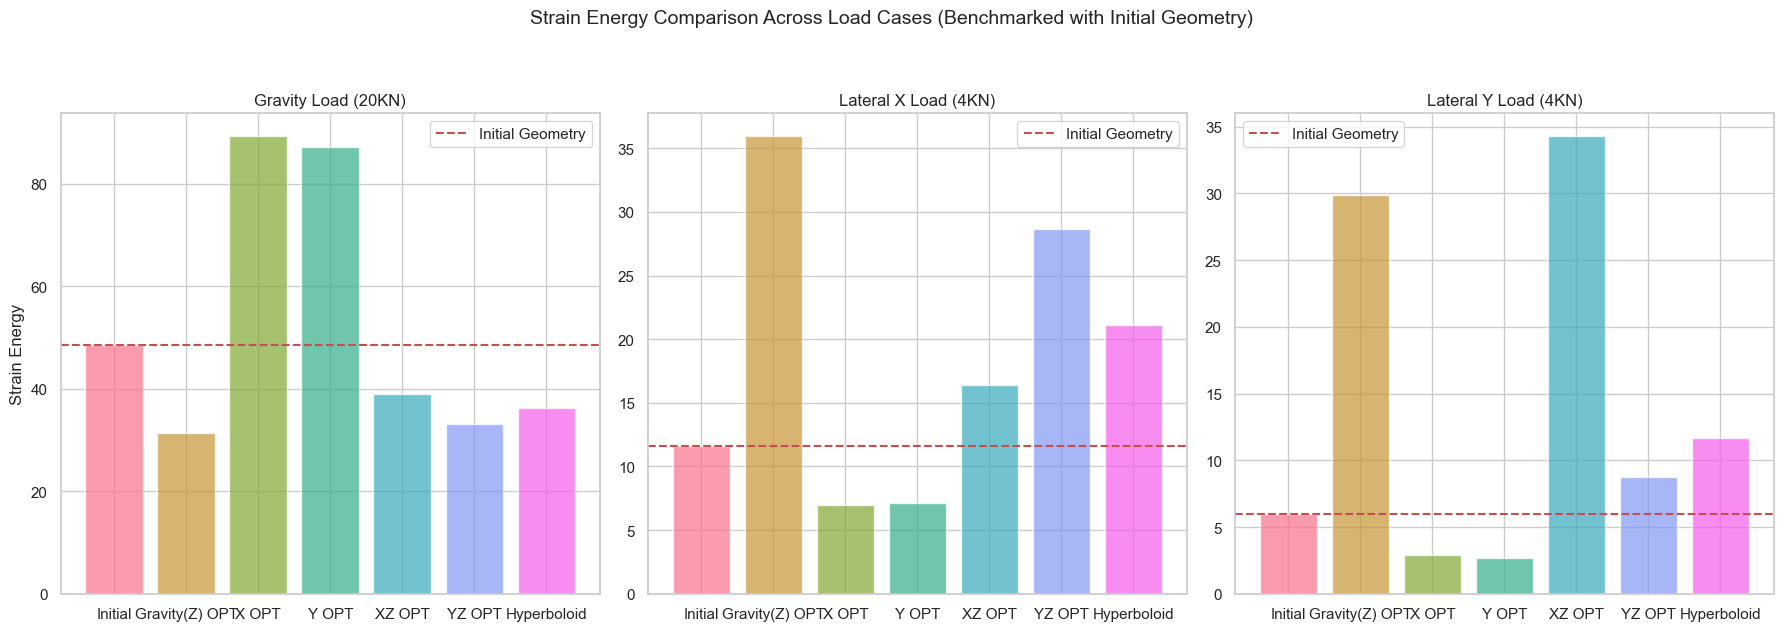

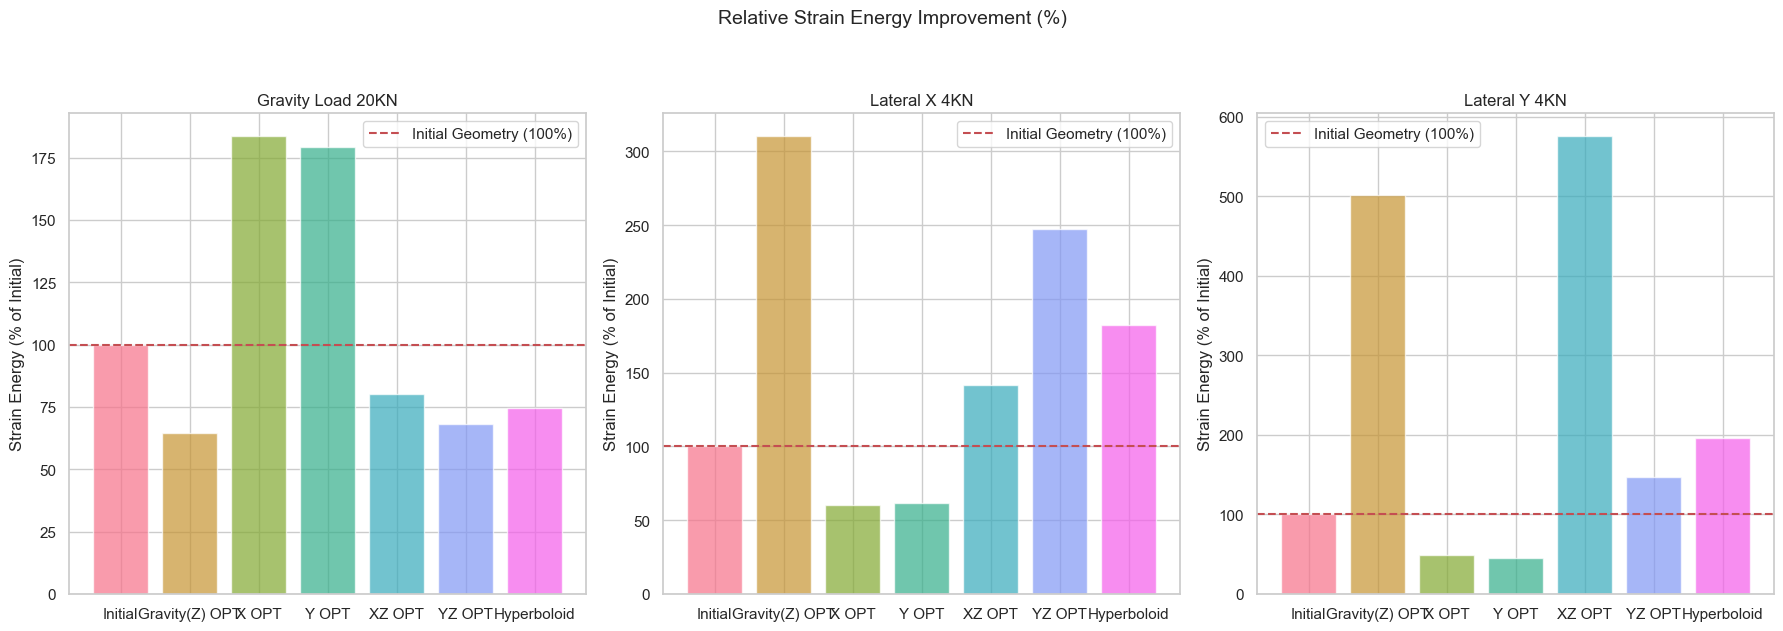

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns  # 导入Seaborn

# 设置Seaborn风格（替代plt.style.use('seaborn')）
sns.set_theme(style="whitegrid")  # 可选风格: "darkgrid", "whitegrid", "dark", "white", "ticks"

# 示例数据（替换为你的实际数据）
data = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid"],
    "Gravity_Load_20KN": [48.61, 31.38, 89.2406, 87.2406,1],  # 初始几何的应变能设为基准
    "Lateral_X_4KN": [11.586, 35.9344, 6.9791, 7.1566, 16.3610],
    "Lateral_Y_4KN": [5.9586, 29.9026, 2.9081, 2.6652, 34.2732]
}

# 转换为DataFrame
df = pd.DataFrame(data)

# 计算相对改进（相对于初始几何）
df_relative = df.copy()
for col in ["Gravity_Load", "Lateral_X", "Lateral_Y"]:
    df_relative[col] = df[col] / df[col][0] * 100  # 以初始几何为基准（100%）

# 设置颜色（Seaborn默认调色板）
colors = sns.color_palette("husl", n_colors=len(df["Design"]))

# 绘制三个工况的柱状图
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Strain Energy Comparison Across Load Cases (Benchmarked with Initial Geometry)", fontsize=14, y=1.05)

# 工况1: Gravity Load 20KN
axes[0].bar(df["Design"], df["Gravity_Load_20KN"], color=colors, alpha=0.7)
axes[0].set_title("Gravity Load (20KN)")
axes[0].set_ylabel("Strain Energy")
axes[0].axhline(y=df["Gravity_Load_20KN"][0], color='r', linestyle='--', label="Initial Geometry")
axes[0].legend()

# 工况2: Lateral X Load 4KN
axes[1].bar(df["Design"], df["Lateral_X_4KN"], color=colors, alpha=0.7)
axes[1].set_title("Lateral X Load (4KN)")
axes[1].axhline(y=df["Lateral_X_4KN"][0], color='r', linestyle='--', label="Initial Geometry")
axes[1].legend()

# 工况3: Lateral Y Load 4KN
axes[2].bar(df["Design"], df["Lateral_Y_4KN"], color=colors, alpha=0.7)
axes[2].set_title("Lateral Y Load (4KN)")
axes[2].axhline(y=df["Lateral_Y_4KN"][0], color='r', linestyle='--', label="Initial Geometry")
axes[2].legend()

# 调整布局
plt.tight_layout()
plt.show()

# 可选：绘制相对改进图（百分比）
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6))
fig2.suptitle("Relative Strain Energy Improvement (%)", fontsize=14, y=1.05)

for i, col in enumerate(["Gravity_Load_20KN", "Lateral_X_4KN", "Lateral_Y_4KN"]):
    axes2[i].bar(df["Design"], df_relative[col], color=colors, alpha=0.7)
    axes2[i].set_title(col.replace("_", " "))
    axes2[i].axhline(y=100, color='r', linestyle='--', label="Initial Geometry (100%)")
    axes2[i].set_ylabel("Strain Energy (% of Initial)")
    axes2[i].legend()

plt.tight_layout()
plt.show()


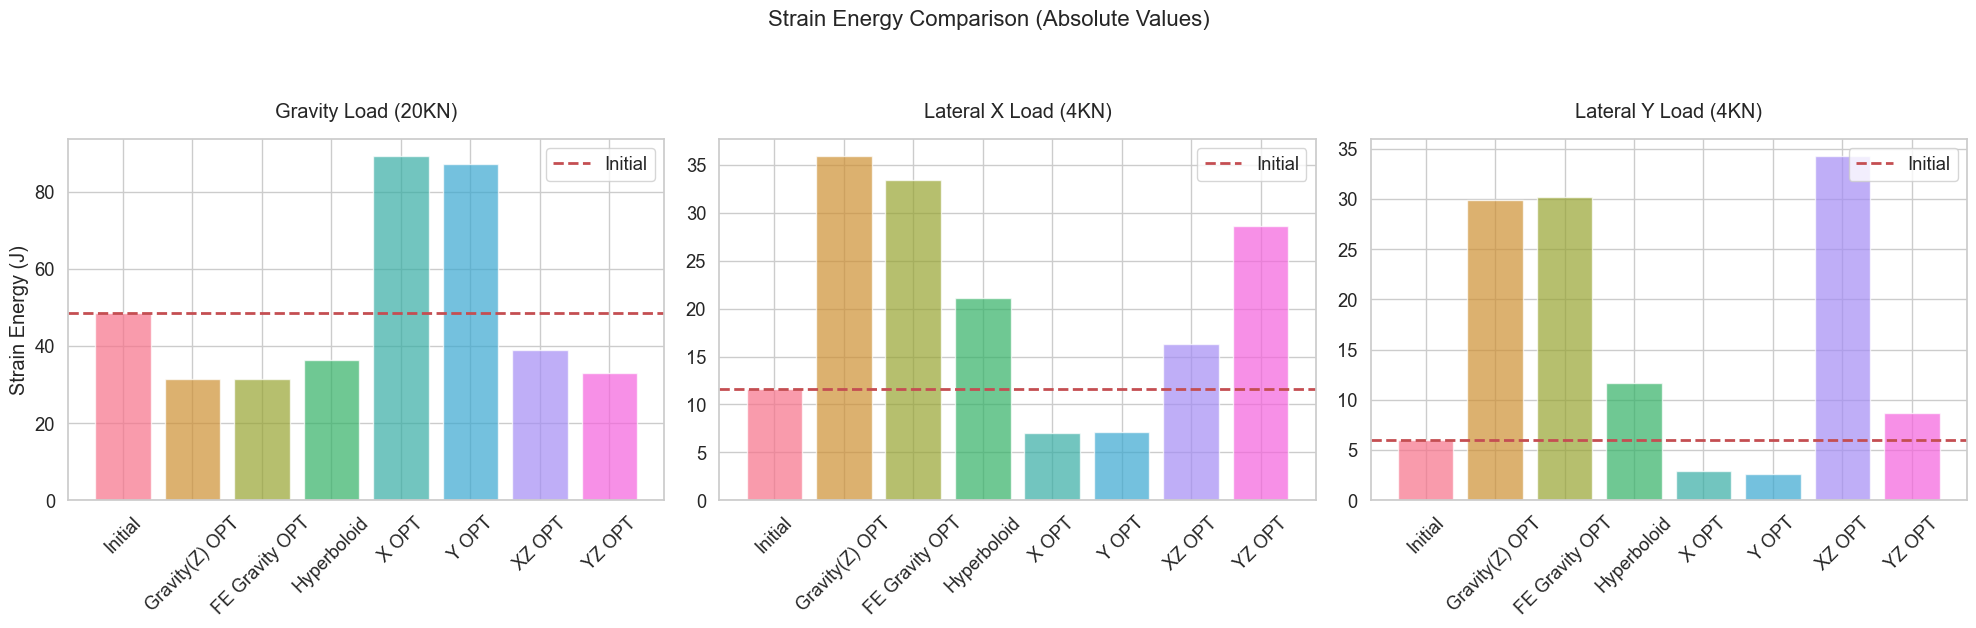

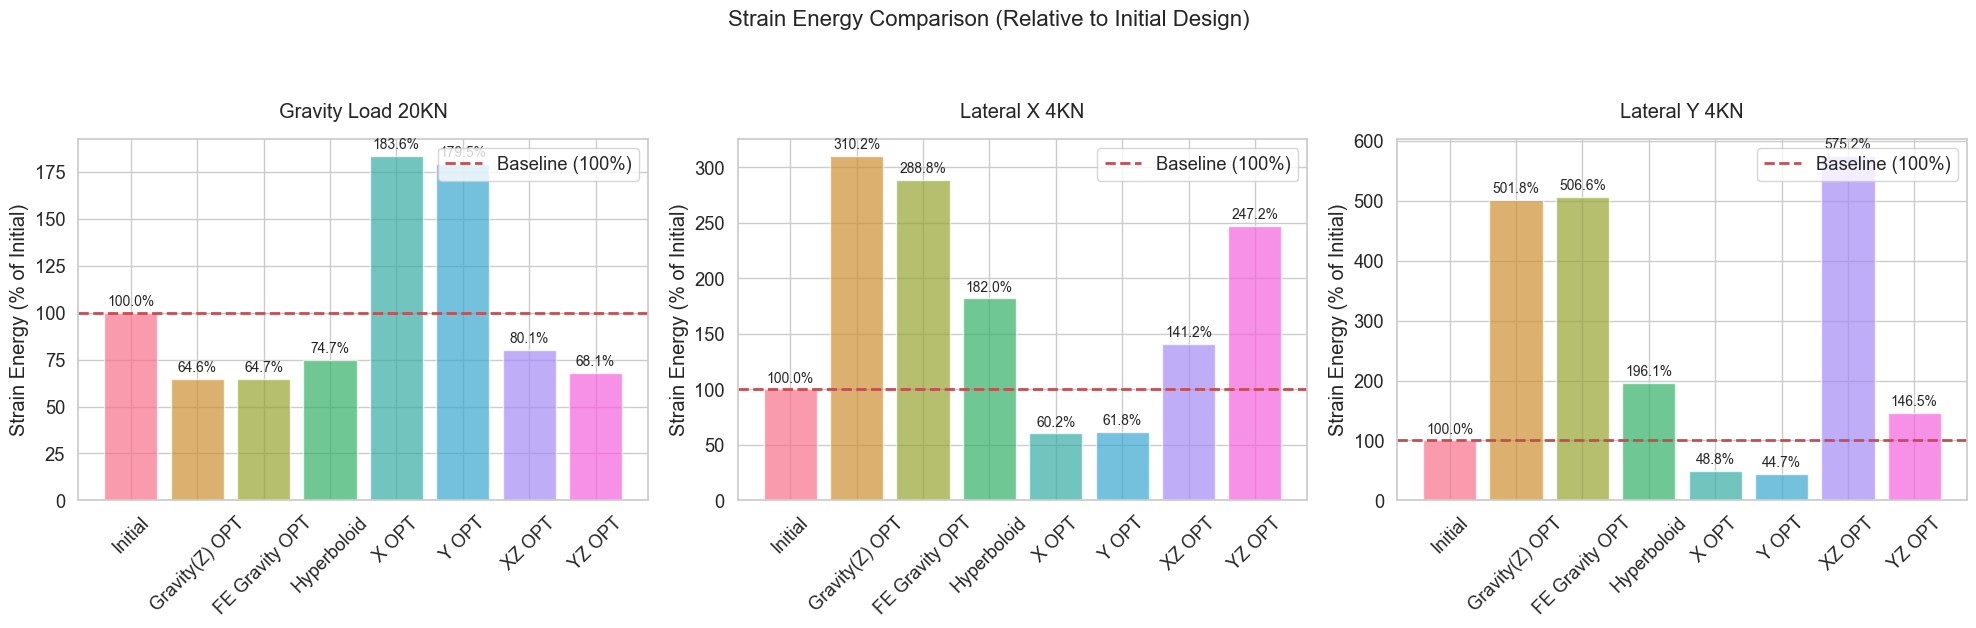

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 设置Seaborn风格
sns.set_theme(style="whitegrid", font_scale=1.2)

# 数据
data = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid"],
    "Gravity_Load_20KN": [48.61, 31.38, 89.2406, 87.2406,1],  # 初始几何的应变能设为基准
    "Lateral_X_4KN": [11.586, 35.9344, 6.9791, 7.1566, 16.3610],
    "Lateral_Y_4KN": [5.9586, 29.9026, 2.9081, 2.6652, 34.2732]
}


# 转换为DataFrame
df = pd.DataFrame(data)

# 计算相对改进（百分比）
df_relative = df.copy()
for col in ["Gravity_Load_20KN", "Lateral_X_4KN", "Lateral_Y_4KN"]:
    df_relative[col] = df[col] / df[col][0] * 100

# 设置颜色
colors = sns.color_palette("husl", n_colors=len(df["Design"]))

# ========== 第一张图：绝对应变能 ==========
fig1, axes = plt.subplots(1, 3, figsize=(20, 6))
fig1.suptitle("Strain Energy Comparison (Absolute Values)", fontsize=16, y=1.05)

# 重力荷载
axes[0].bar(df["Design"], df["Gravity_Load_20KN"], color=colors, alpha=0.7)
axes[0].set_title("Gravity Load (20KN)", pad=15)
axes[0].set_ylabel("Strain Energy (J)")
axes[0].axhline(y=df["Gravity_Load_20KN"][0], color='r', linestyle='--', linewidth=2, label="Initial")
axes[0].legend(loc='upper right')
axes[0].tick_params(axis='x', rotation=45)

# X方向侧向荷载
axes[1].bar(df["Design"], df["Lateral_X_4KN"], color=colors, alpha=0.7)
axes[1].set_title("Lateral X Load (4KN)", pad=15)
axes[1].axhline(y=df["Lateral_X_4KN"][0], color='r', linestyle='--', linewidth=2, label="Initial")
axes[1].legend(loc='upper right')
axes[1].tick_params(axis='x', rotation=45)

# Y方向侧向荷载
axes[2].bar(df["Design"], df["Lateral_Y_4KN"], color=colors, alpha=0.7)
axes[2].set_title("Lateral Y Load (4KN)", pad=15)
axes[2].axhline(y=df["Lateral_Y_4KN"][0], color='r', linestyle='--', linewidth=2, label="Initial")
axes[2].legend(loc='upper right')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("Strain_Energy_Absolute.png", dpi=300, bbox_inches='tight')  # 保存第一张图
plt.show()


# ========== 第二张图：相对改进百分比 ==========
fig2, axes = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle("Strain Energy Comparison (Relative to Initial Design)", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load_20KN", "Lateral_X_4KN", "Lateral_Y_4KN"]):
    # 绘制柱状图
    bars = axes[i].bar(df["Design"], df_relative[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("Strain Energy (% of Initial)")
    axes[i].axhline(y=100, color='r', linestyle='--', linewidth=2, label="Baseline (100%)")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # 在柱子上方添加百分比标签（保留1位小数）
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_relative[col]],  # 格式化标签
        padding=3,  # 标签与柱子的距离
        fontsize=10  # 标签字体大小
    )

plt.tight_layout()
plt.savefig("Strain_Energy_Relative.png", dpi=300, bbox_inches='tight')
plt.show()


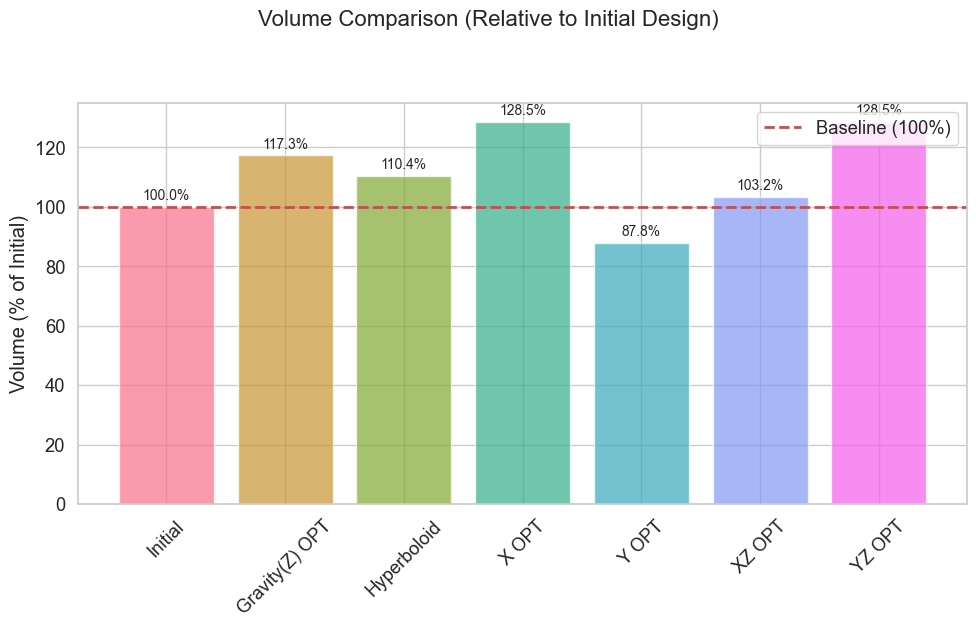

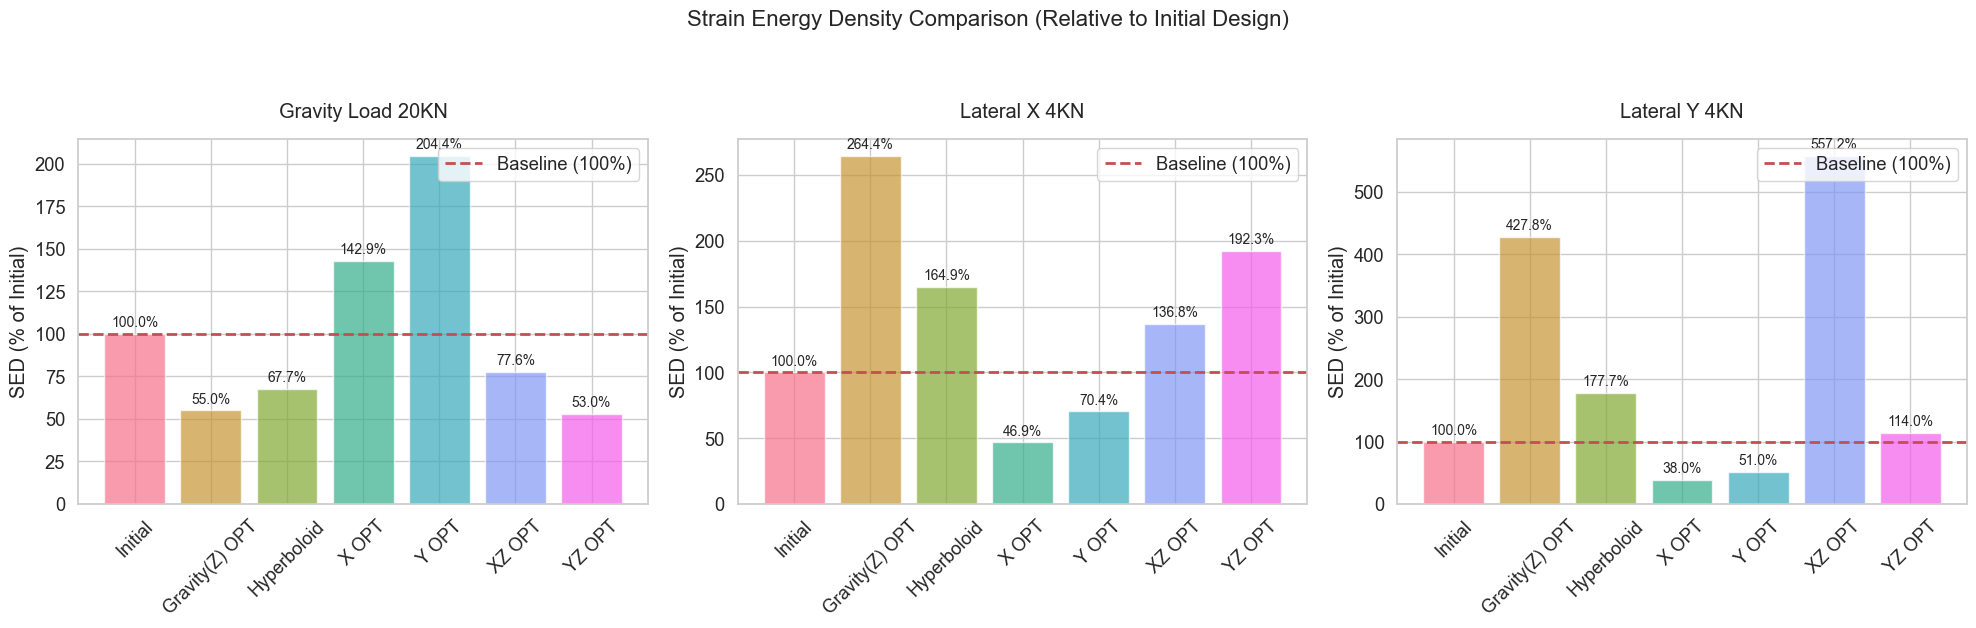

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 设置Seaborn风格
sns.set_theme(style="whitegrid", font_scale=1.2)

# 数据
data = {
    "Design": ["Initial", "Gravity(Z) OPT", "Hyperboloid", "X OPT", "Y OPT", "XZ OPT", "YZ OPT"],
    "Gravity_Load_20KN": [48.61, 31.38, 36.334, 89.2406, 87.2406, 38.9608, 33.1245],
    "Lateral_X_4KN": [11.586, 35.9344, 21.0823, 6.9791, 7.1566, 16.3610, 28.6378],
    "Lateral_Y_4KN": [5.9586, 29.9026, 11.6826, 2.9081, 2.6652, 34.2732, 8.7271],  # Fixed case to match others
    "Volume": [468.2144, 549.2471, 516.6955, 601.711, 411.0169, 483.3359, 601.7064]  # 假设的7个体积数据，Initial=100作为基准
}

# 转换为DataFrame
df = pd.DataFrame(data)

# 计算相对改进（百分比）
df_relative = df.copy()
for col in ["Gravity_Load_20KN", "Lateral_X_4KN", "Lateral_Y_4KN", "Volume"]:  # Fixed case here
    df_relative[col] = df[col] / df[col][0] * 100

# 计算SED (应变能密度 = 应变能/体积)
df_sed = df.copy()
for col in ["Gravity_Load_20KN", "Lateral_X_4KN", "Lateral_Y_4KN"]:  # Fixed case here
    df_sed[col] = df[col] / df["Volume"]

# 计算SED的相对百分比
df_sed_relative = df_sed.copy()
for col in ["Gravity_Load_20KN", "Lateral_X_4KN", "Lateral_Y_4KN"]:  # Fixed case here
    df_sed_relative[col] = df_sed[col] / df_sed[col][0] * 100

# 设置颜色
colors = sns.color_palette("husl", n_colors=len(df["Design"]))

# ========== 第一张图：体积对比 ==========
fig1, ax = plt.subplots(figsize=(10, 6))
fig1.suptitle("Volume Comparison (Relative to Initial Design)", fontsize=16, y=1.05)

# 绘制柱状图
bars = ax.bar(df["Design"], df_relative["Volume"], color=colors, alpha=0.7)
ax.set_ylabel("Volume (% of Initial)")
ax.axhline(y=100, color='r', linestyle='--', linewidth=2, label="Baseline (100%)")
ax.legend(loc='upper right')
ax.tick_params(axis='x', rotation=45)

# 在柱子上方添加百分比标签
ax.bar_label(
    bars, 
    labels=[f"{val:.1f}%" for val in df_relative["Volume"]],
    padding=3,
    fontsize=10
)

plt.tight_layout()
plt.savefig("Volume_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== 第二张图：SED对比 ==========
fig2, axes = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle("Nomalised Strain Energy Comparison (Relative to Initial Design)", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load_20KN", "Lateral_X_4KN", "Lateral_Y_4KN"]):  # Fixed case here
    # 绘制柱状图
    bars = axes[i].bar(df["Design"], df_sed_relative[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("SE * V (% of Initial)")
    axes[i].axhline(y=100, color='r', linestyle='--', linewidth=2, label="Baseline (100%)")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # 在柱子上方添加百分比标签
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_sed_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("SEV_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()

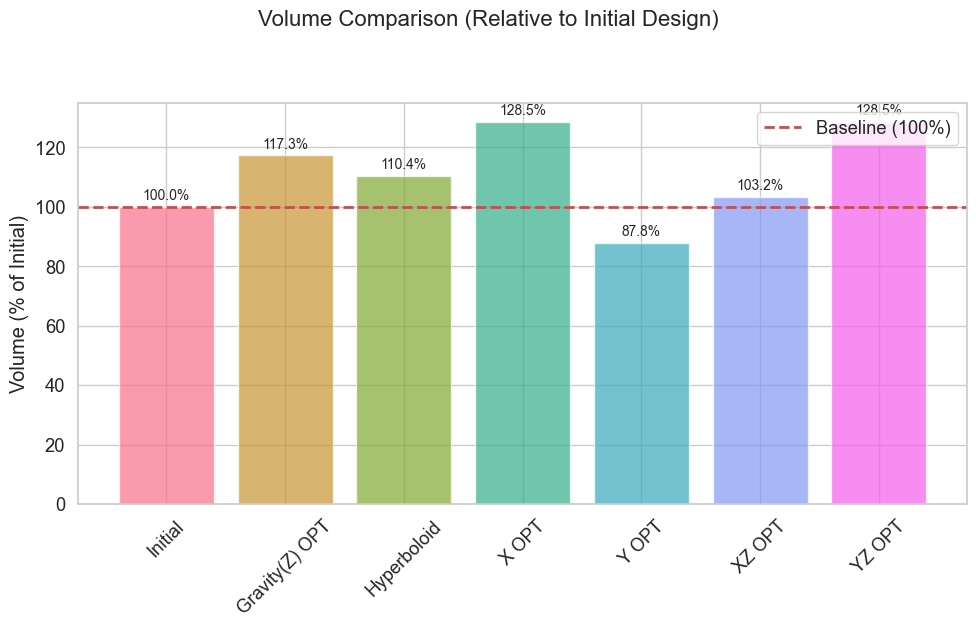

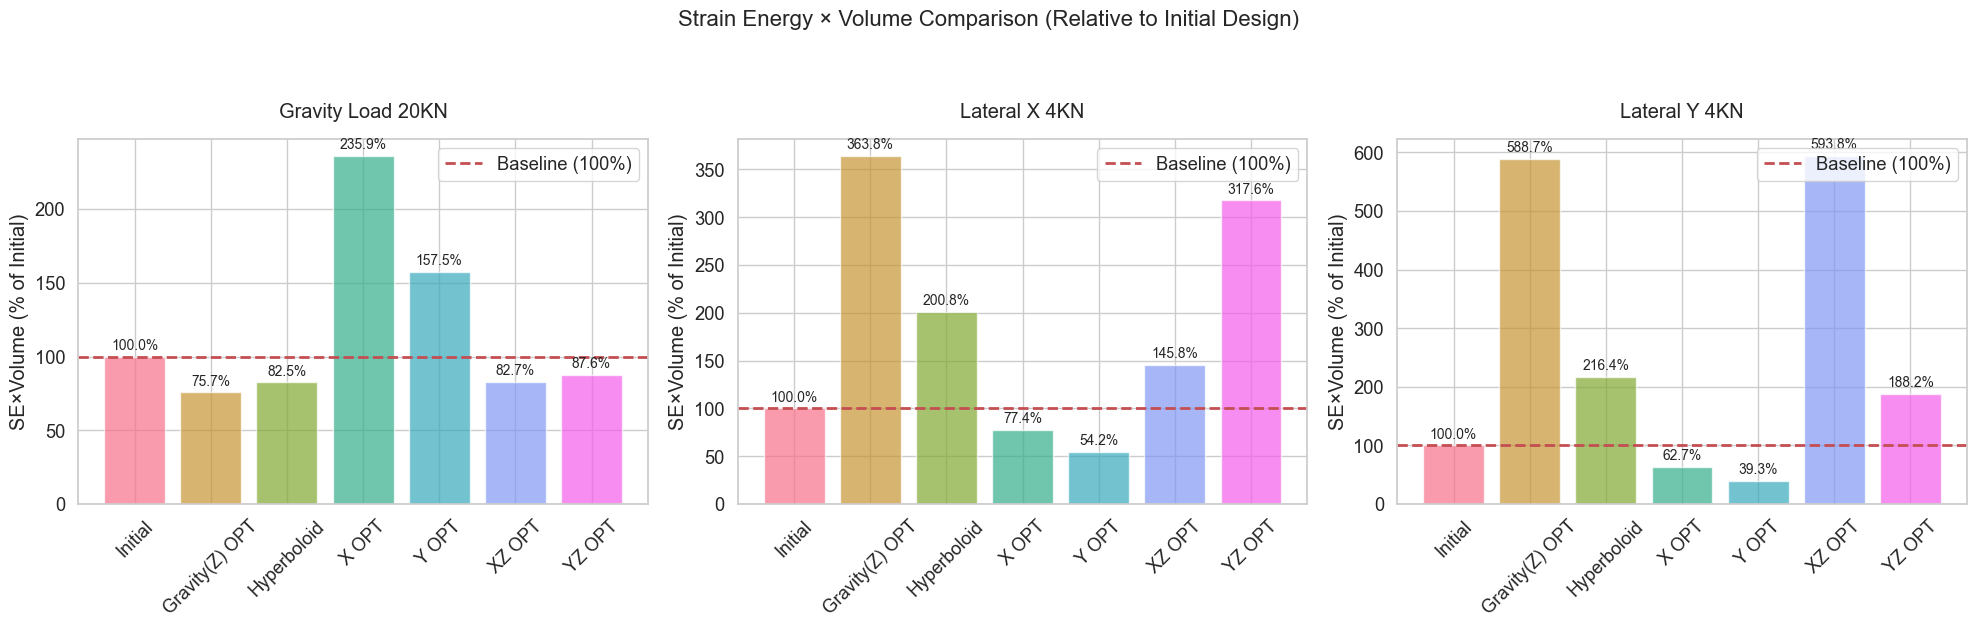

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 设置Seaborn风格
sns.set_theme(style="whitegrid", font_scale=1.2)

# 数据（保持原数据不变）
data = {
    "Design": ["Initial", "Gravity(Z) OPT", "Hyperboloid", "X OPT", "Y OPT", "XZ OPT", "YZ OPT"],
    "Gravity_Load_20KN": [48.61, 31.38, 36.334, 89.2406, 87.2406, 38.9608, 33.1245],
    "Lateral_X_4KN": [11.586, 35.9344, 21.0823, 6.9791, 7.1566, 16.3610, 28.6378],
    "Lateral_Y_4KN": [5.9586, 29.9026, 11.6826, 2.9081, 2.6652, 34.2732, 8.7271],
    "Volume": [468.2144, 549.2471, 516.6955, 601.711, 411.0169, 483.3359, 601.7064]
}

# 转换为DataFrame
df = pd.DataFrame(data)

# 计算相对改进（百分比）
df_relative = df.copy()
for col in ["Gravity_Load_20KN", "Lateral_X_4KN", "Lateral_Y_4KN", "Volume"]:
    df_relative[col] = df[col] / df[col][0] * 100

# 计算 SE×Volume（应变能 × 体积）
df_se_volume = df.copy()
for col in ["Gravity_Load_20KN", "Lateral_X_4KN", "Lateral_Y_4KN"]:
    df_se_volume[col] = df[col] * df["Volume"]  # 修改为乘法

# 计算 SE×Volume 的相对百分比
df_se_volume_relative = df_se_volume.copy()
for col in ["Gravity_Load_20KN", "Lateral_X_4KN", "Lateral_Y_4KN"]:
    df_se_volume_relative[col] = df_se_volume[col] / df_se_volume[col][0] * 100

# 设置颜色
colors = sns.color_palette("husl", n_colors=len(df["Design"]))

# ========== 第一张图：体积对比 ==========
fig1, ax = plt.subplots(figsize=(10, 6))
fig1.suptitle("Volume Comparison (Relative to Initial Design)", fontsize=16, y=1.05)

bars = ax.bar(df["Design"], df_relative["Volume"], color=colors, alpha=0.7)
ax.set_ylabel("Volume (% of Initial)")
ax.axhline(y=100, color='r', linestyle='--', linewidth=2, label="Baseline (100%)")
ax.legend(loc='upper right')
ax.tick_params(axis='x', rotation=45)

# 添加百分比标签
ax.bar_label(bars, labels=[f"{val:.1f}%" for val in df_relative["Volume"]], padding=3, fontsize=10)

plt.tight_layout()
plt.savefig("Volume_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== 第二张图：SE×Volume 对比 ==========
fig2, axes = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle("Strain Energy × Volume Comparison (Relative to Initial Design)", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load_20KN", "Lateral_X_4KN", "Lateral_Y_4KN"]):
    bars = axes[i].bar(df["Design"], df_se_volume_relative[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("SE×Volume (% of Initial)")
    axes[i].axhline(y=100, color='r', linestyle='--', linewidth=2, label="Baseline (100%)")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # 添加百分比标签
    axes[i].bar_label(bars, labels=[f"{val:.1f}%" for val in df_se_volume_relative[col]], padding=3, fontsize=10)

plt.tight_layout()
plt.savefig("SE_Volume_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()

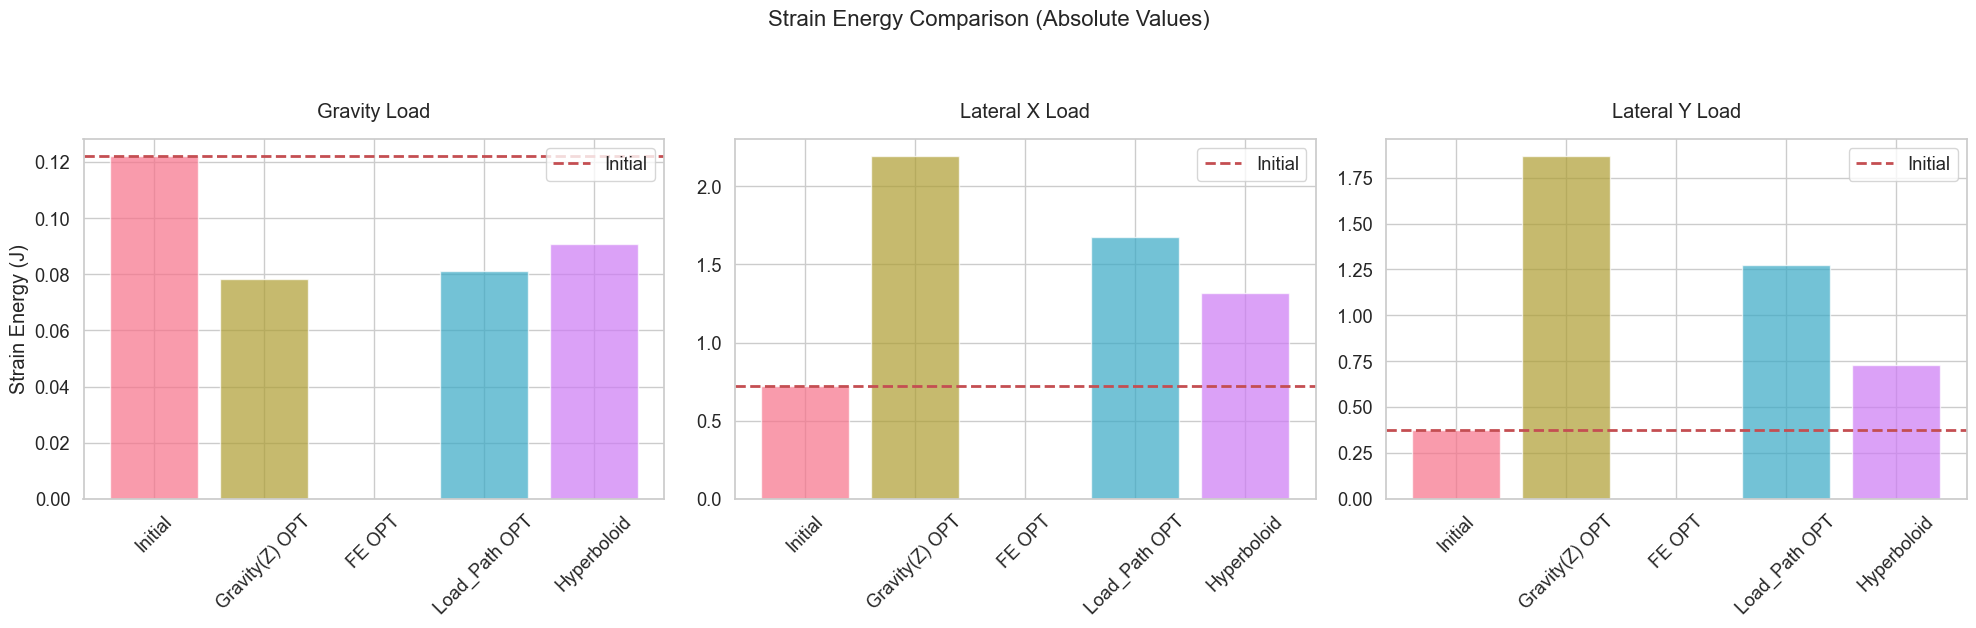

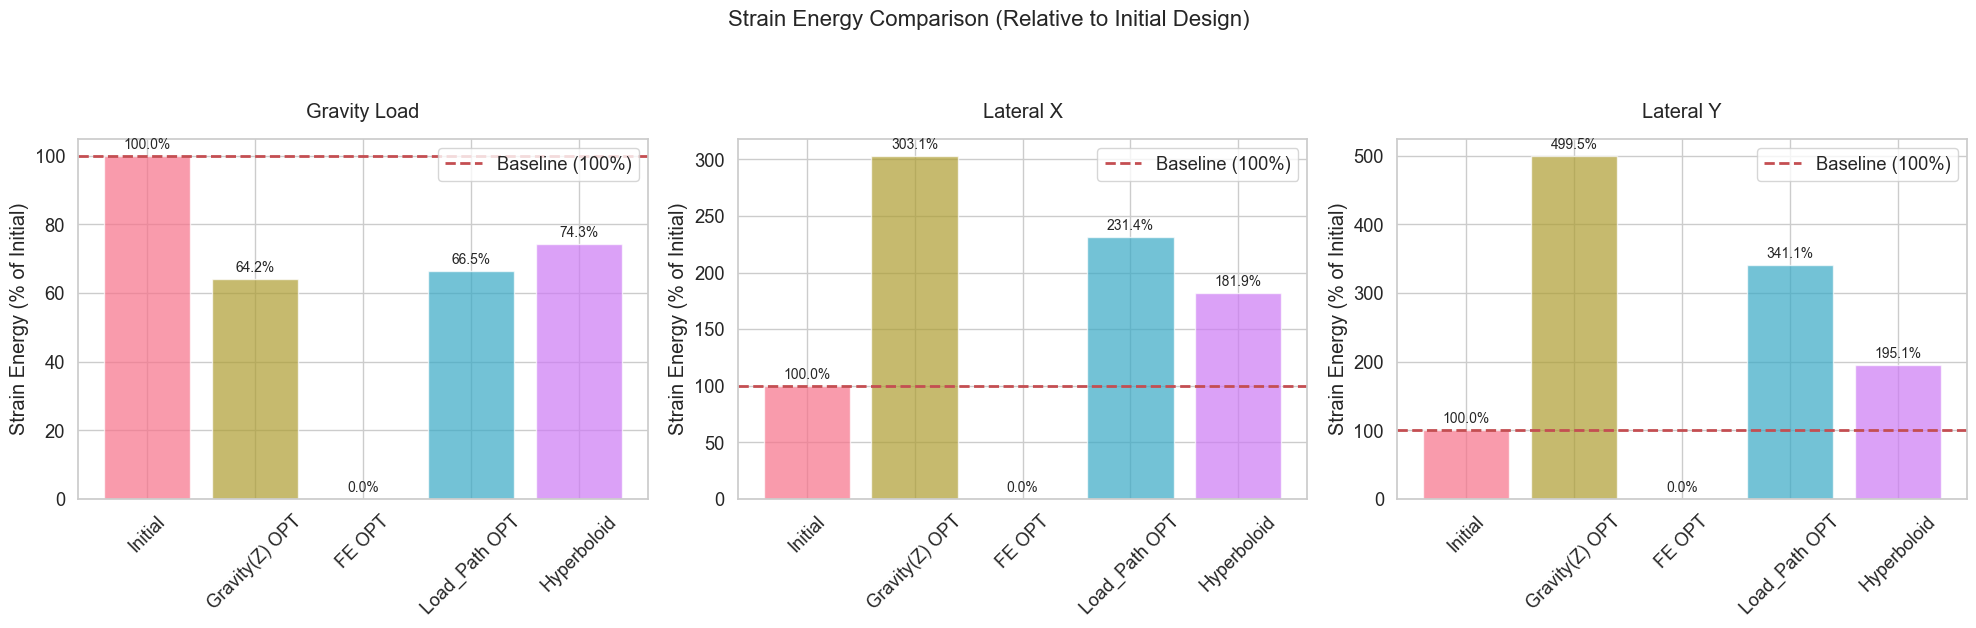

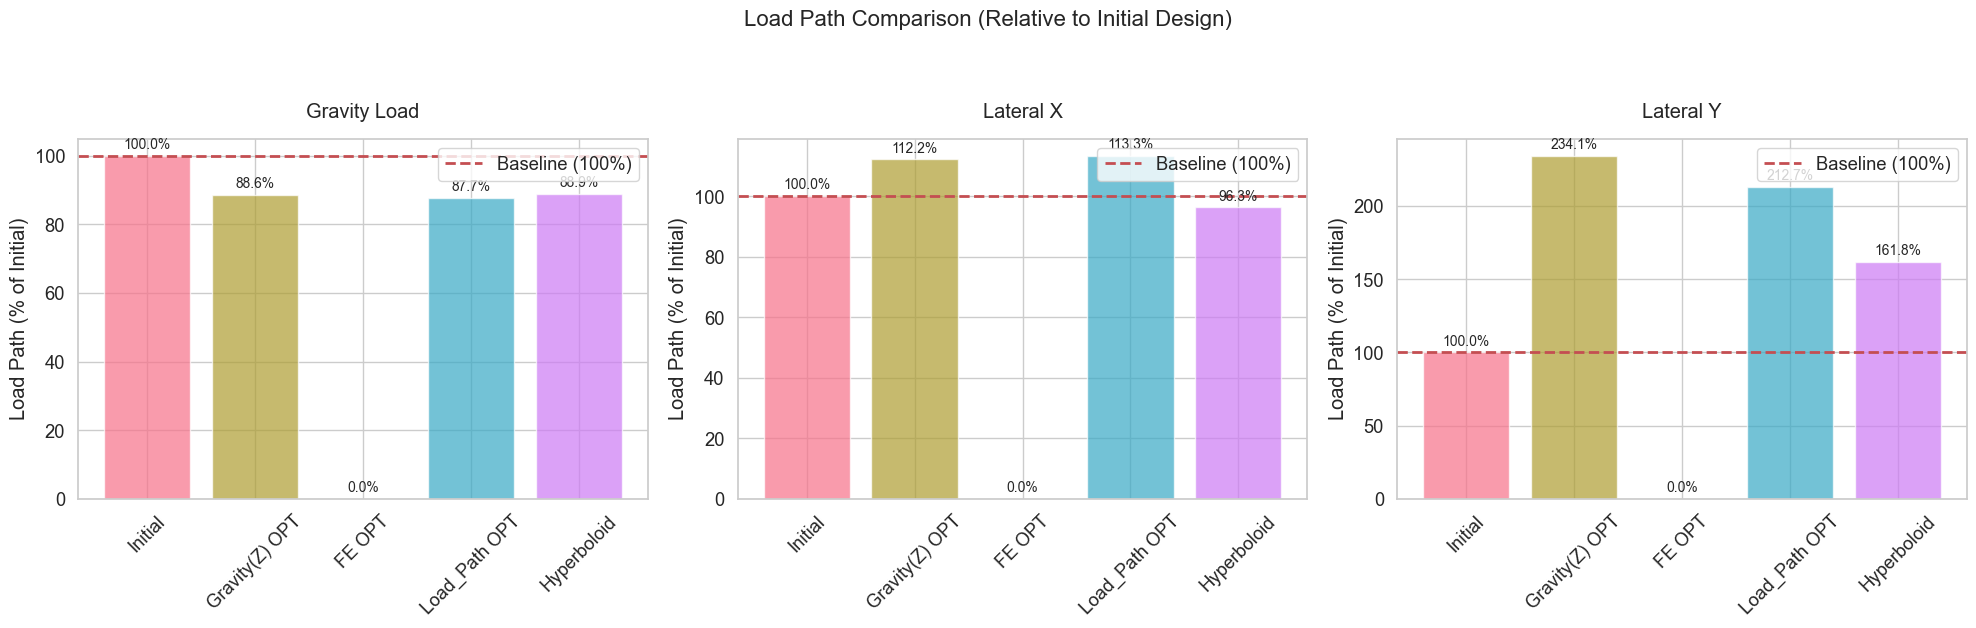

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set Seaborn style
sns.set_theme(style="whitegrid", font_scale=1.2)

# Data - Strain Energy (note consistent capitalization)
data_se = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid"],
    "Gravity_Load": [0.1222, 0.0785, 0, 0.0813, 0.0015], 
    "Lateral_X": [0.7242, 2.1950, 0, 1.6761, 0.0012],
    "Lateral_Y": [0.3742, 1.8693 ,0, 1.2764, 0.0013],  # Changed to capital Y
}

# Data - Load Path (note consistent capitalization)
data_lp = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid"],
    "Gravity_Load": [1094050.25, 968963.75, 0, 960007.375, 972312],
    "Lateral_X": [190077.4375, 213214.76, 0, 215414.72, 183010.9375],
    "Lateral_Y": [53343.7969, 124898.95, 0, 113471.6875, 86287.96],  # Changed to capital Y
}

# Convert to DataFrames
df_se = pd.DataFrame(data_se)
df_lp = pd.DataFrame(data_lp)

# Calculate relative improvements (%)
df_se_relative = df_se.copy()
df_lp_relative = df_lp.copy()

# Use consistent column names (all with capital Y)
for col in ["Gravity_Load", "Lateral_X", "Lateral_Y"]:  # Changed to capital Y
    df_se_relative[col] = df_se[col] / df_se[col][0] * 100
    df_lp_relative[col] = df_lp[col] / df_lp[col][0] * 100

# Set colors
colors = sns.color_palette("husl", n_colors=len(df_se["Design"]))

# ========== Plot 1: Absolute Strain Energy ==========
fig1, axes = plt.subplots(1, 3, figsize=(20, 6))
fig1.suptitle("Strain Energy Comparison (Absolute Values)", fontsize=16, y=1.05)

# Gravity Load
axes[0].bar(df_se["Design"], df_se["Gravity_Load"], color=colors, alpha=0.7)
axes[0].set_title("Gravity Load", pad=15)
axes[0].set_ylabel("Strain Energy (J)")
axes[0].axhline(y=df_se["Gravity_Load"][0], color='r', linestyle='--', linewidth=2, label="Initial")
axes[0].legend(loc='upper right')
axes[0].tick_params(axis='x', rotation=45)

# X-direction lateral load
axes[1].bar(df_se["Design"], df_se["Lateral_X"], color=colors, alpha=0.7)
axes[1].set_title("Lateral X Load", pad=15)
axes[1].axhline(y=df_se["Lateral_X"][0], color='r', linestyle='--', linewidth=2, label="Initial")
axes[1].legend(loc='upper right')
axes[1].tick_params(axis='x', rotation=45)

# Y-direction lateral load
axes[2].bar(df_se["Design"], df_se["Lateral_Y"], color=colors, alpha=0.7)  # Changed to capital Y
axes[2].set_title("Lateral Y Load", pad=15)
axes[2].axhline(y=df_se["Lateral_Y"][0], color='r', linestyle='--', linewidth=2, label="Initial")  # Changed to capital Y
axes[2].legend(loc='upper right')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("Strain_Energy_Absolute.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== Plot 2: Relative Strain Energy ==========
fig2, axes = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle("Strain Energy Comparison (Relative to Initial Design)", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):  # Changed to capital Y
    bars = axes[i].bar(df_se["Design"], df_se_relative[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("Strain Energy (% of Initial)")
    axes[i].axhline(y=100, color='r', linestyle='--', linewidth=2, label="Baseline (100%)")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_se_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("Strain_Energy_Relative.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== Plot 3: Relative Load Path ==========
fig3, axes = plt.subplots(1, 3, figsize=(20, 6))
fig3.suptitle("Load Path Comparison (Relative to Initial Design)", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):  # Changed to capital Y
    bars = axes[i].bar(df_lp["Design"], df_lp_relative[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("Load Path (% of Initial)")
    axes[i].axhline(y=100, color='r', linestyle='--', linewidth=2, label="Baseline (100%)")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_lp_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("Load_Path_Relative.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子以便结果可复现
np.random.seed(42)

# 创建三条不同长度的优化历史数据
# 每条数据包含(x, y)坐标，x代表迭代步数，y代表优化目标值

# 第一条曲线: 20个点，步长0.5
x1 = np.arange(0, 10, 0.5)
y1 = np.exp(-x1/3) + np.random.normal(0, 0.02, len(x1))

# 第二条曲线: 15个点，步长0.8
x2 = np.arange(0, 12, 0.8)
y2 = np.exp(-x2/4) + 0.2 + np.random.normal(0, 0.03, len(x2))

# 第三条曲线: 30个点，步长0.3
x3 = np.arange(0, 9, 0.3)
y3 = np.exp(-x3/2.5) + 0.4 + np.random.normal(0, 0.01, len(x3))

# 创建图形
plt.figure(figsize=(10, 6))

# 绘制三条曲线，使用不同的颜色和标记样式
plt.plot(x1, y1, 'o-', color='blue', label='优化历史1 (20点, 步长0.5)', markersize=6, linewidth=1.5)
plt.plot(x2, y2, 's--', color='green', label='优化历史2 (15点, 步长0.8)', markersize=6, linewidth=1.5)
plt.plot(x3, y3, 'd-.', color='red', label='优化历史3 (30点, 步长0.3)', markersize=6, linewidth=1.5)

# 添加标题和标签
plt.title('不同长度和步长的优化历史比较', fontsize=14)
plt.xlabel('迭代次数', fontsize=12)
plt.ylabel('目标函数值', fontsize=12)

# 添加图例
plt.legend(fontsize=10)

# 添加网格
plt.grid(True, linestyle='--', alpha=0.6)

# 调整坐标轴范围
plt.xlim(-0.5, max(max(x1), max(x2), max(x3)) + 0.5)
plt.ylim(0, 1.2)

# 显示图形
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set Seaborn style
sns.set_theme(style="whitegrid", font_scale=1.2)

# Data - Strain Energy (note consistent capitalization)
data_se = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid"],
    "Gravity_Load": [0.1222, 1.8730, 0, 0.0813, 0.0041], 
    "Lateral_X": [0.7242, 2.1950, 0, 1.6761, 0.0221],
    "Lateral_Y": [0.3742, 1.8730 ,0, 1.2764, 0.7302],  # Changed to capital Y
}

# Data - Load Path (note consistent capitalization)
data_lp = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid"],
    "Gravity_Load": [1094050.25, 968963.75, 0, 960007.375, 800023.7500],
    "Lateral_X": [190077.4375, 213214.76, 0, 215414.72, 348005.1562],
    "Lateral_Y": [53343.7969, 124898.95, 0, 113471.6875, 86287.96],  # Changed to capital Y
}

# Convert to DataFrames
df_se = pd.DataFrame(data_se)
df_lp = pd.DataFrame(data_lp)

# Calculate relative improvements (%)
df_se_relative = df_se.copy()
df_lp_relative = df_lp.copy()

# Use consistent column names (all with capital Y)
for col in ["Gravity_Load", "Lateral_X", "Lateral_Y"]:  # Changed to capital Y
    df_se_relative[col] = df_se[col] / df_se[col][0] * 100
    df_lp_relative[col] = df_lp[col] / df_lp[col][0] * 100

# Set colors
colors = sns.color_palette("husl", n_colors=len(df_se["Design"]))

# ========== Plot 1: Absolute Strain Energy ==========
fig1, axes = plt.subplots(1, 3, figsize=(20, 6))
fig1.suptitle("Strain Energy Comparison (Absolute Values)", fontsize=16, y=1.05)

# Gravity Load
axes[0].bar(df_se["Design"], df_se["Gravity_Load"], color=colors, alpha=0.7)
axes[0].set_title("Gravity Load", pad=15)
axes[0].set_ylabel("Strain Energy (J)")
axes[0].axhline(y=df_se["Gravity_Load"][0], color='r', linestyle='--', linewidth=2, label="Initial")
axes[0].legend(loc='upper right')
axes[0].tick_params(axis='x', rotation=45)

# X-direction lateral load
axes[1].bar(df_se["Design"], df_se["Lateral_X"], color=colors, alpha=0.7)
axes[1].set_title("Lateral X Load", pad=15)
axes[1].axhline(y=df_se["Lateral_X"][0], color='r', linestyle='--', linewidth=2, label="Initial")
axes[1].legend(loc='upper right')
axes[1].tick_params(axis='x', rotation=45)

# Y-direction lateral load
axes[2].bar(df_se["Design"], df_se["Lateral_Y"], color=colors, alpha=0.7)  # Changed to capital Y
axes[2].set_title("Lateral Y Load", pad=15)
axes[2].axhline(y=df_se["Lateral_Y"][0], color='r', linestyle='--', linewidth=2, label="Initial")  # Changed to capital Y
axes[2].legend(loc='upper right')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("Strain_Energy_Absolute.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== Plot 2: Relative Strain Energy ==========
fig2, axes = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle("Strain Energy Comparison (Relative to Initial Design)", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):  # Changed to capital Y
    bars = axes[i].bar(df_se["Design"], df_se_relative[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("Strain Energy (% of Initial)")
    axes[i].axhline(y=100, color='r', linestyle='--', linewidth=2, label="Baseline (100%)")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_se_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("Strain_Energy_Relative.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== Plot 3: Relative Load Path ==========
fig3, axes = plt.subplots(1, 3, figsize=(20, 6))
fig3.suptitle("Load Path Comparison (Relative to Initial Design)", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):  # Changed to capital Y
    bars = axes[i].bar(df_lp["Design"], df_lp_relative[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("Load Path (% of Initial)")
    axes[i].axhline(y=100, color='r', linestyle='--', linewidth=2, label="Baseline (100%)")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_lp_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("Load_Path_Relative.png", dpi=300, bbox_inches='tight')
plt.show()

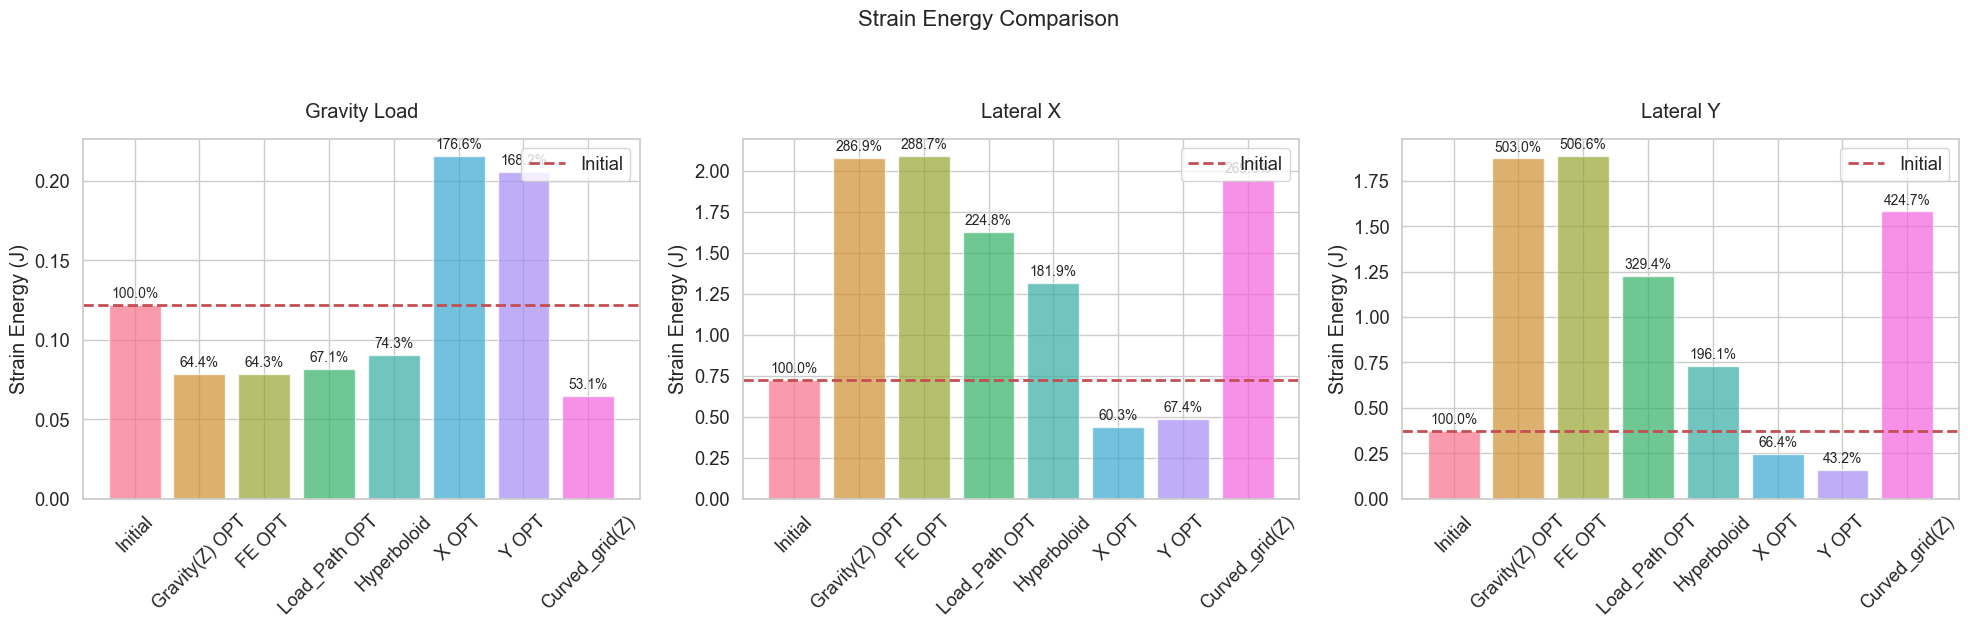

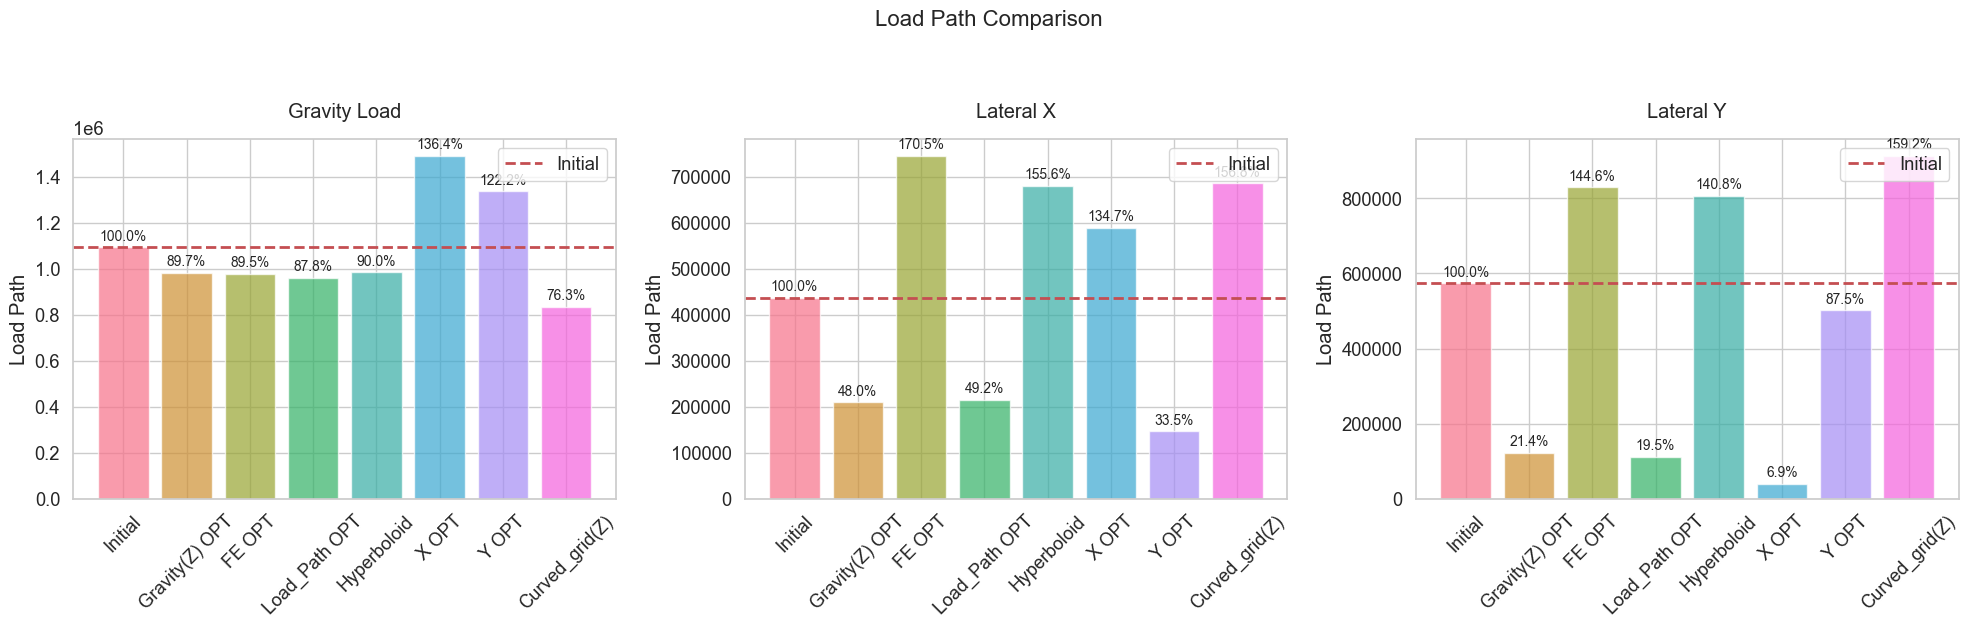

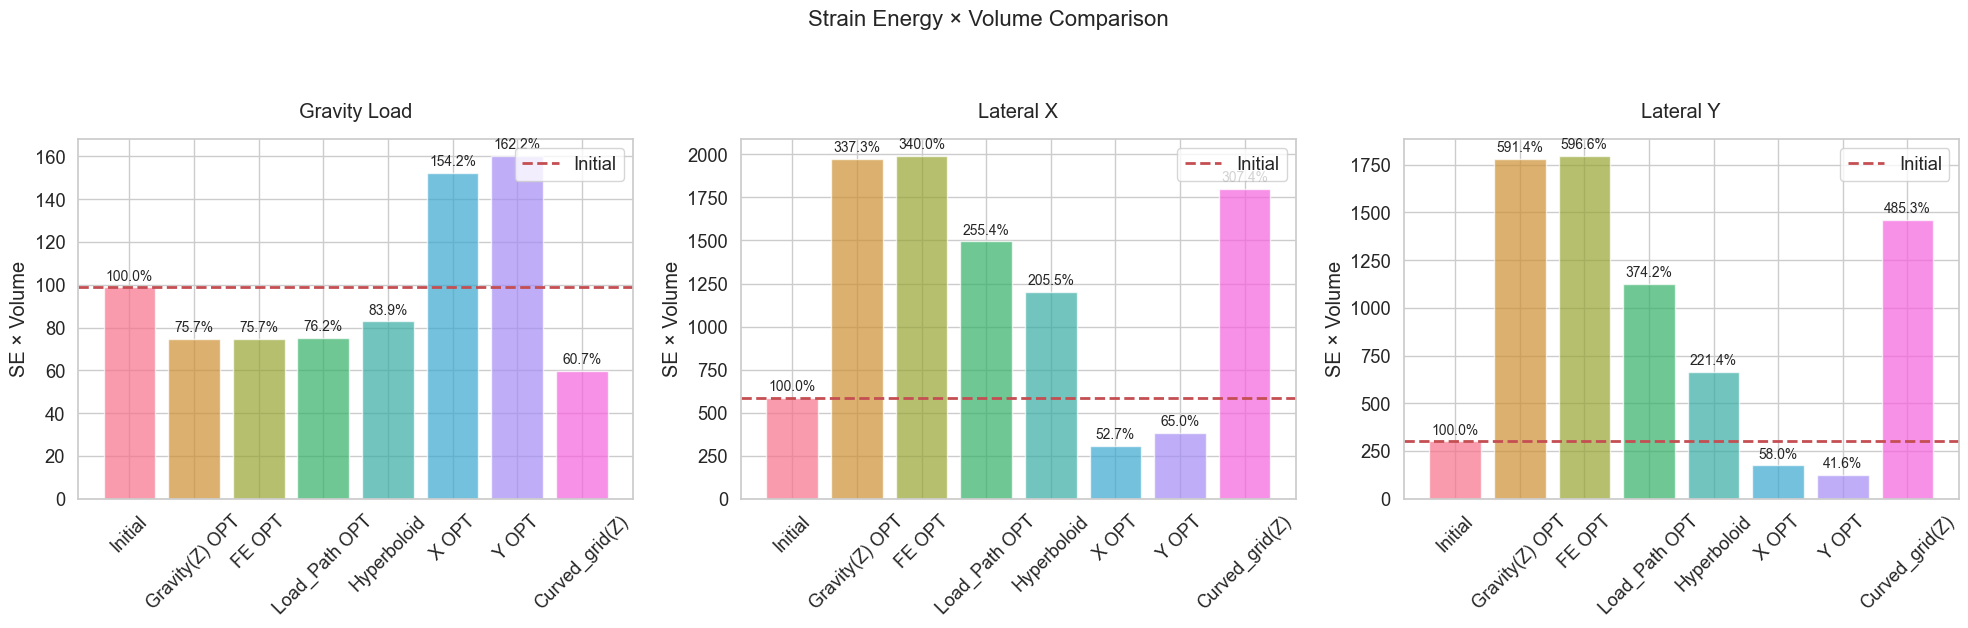

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set Seaborn style
sns.set_theme(style="whitegrid", font_scale=1.2)

# Data - Strain Energy and Volume
data_se = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid","X OPT", "Y OPT", "Curved_grid(Z)"],
    "Gravity_Load": [0.1222, 0.0787, 0.0786, 0.0820, 0.0908, 0.2158, 0.2056, 0.0649], 
    "Lateral_X": [0.7242, 2.0775, 2.0911, 1.6279, 1.3176, 0.4369, 0.4884, 1.9484],
    "Lateral_Y": [0.3724, 1.8730, 1.8866 , 1.2266, 0.7302, 0.2473, 0.1609,1.5817],
    "Volume": [808.5354, 950.7169, 952.1912, 918.5100, 913.0774, 706.0973, 779.3370,923.7530]
}

# Data - Load Path
data_lp = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid","X OPT", "Y OPT", "Curved_grid(Z)"],
    "Gravity_Load": [1094050.2500, 981475.8125, 978795.1250, 960317.6250, 984655.5000, 1491904.7500, 1337246.5000, 835163.0625],
    "Lateral_X": [437452.8750, 209818.5625, 745746.0625, 215403.4375, 680823.6250, 589404.0 , 146582.9375,686064.5000],
    "Lateral_Y": [573551.6875, 122979.0938, 829127.6250, 111596.7188, 807425.8750, 39605.6719, 501817.5625,913112.2500],
    "Volume": [1.0, 1.0, 1.0, 1.0, 1.0, 0, 1.0, 1.0]
}

# Convert to DataFrames
df_se = pd.DataFrame(data_se)
df_lp = pd.DataFrame(data_lp)

# Calculate relative improvements (%)
df_se_relative = df_se.copy()
df_lp_relative = df_lp.copy()
df_se_volume_relative = df_se.copy()

for col in ["Gravity_Load", "Lateral_X", "Lateral_Y"]:
    df_se_relative[col] = df_se[col] / df_se[col][0] * 100
    df_lp_relative[col] = df_lp[col] / df_lp[col][0] * 100
    df_se_volume_relative[col] = (df_se[col] * df_se["Volume"]) / (df_se[col][0] * df_se["Volume"][0]) * 100

# Set colors
colors = sns.color_palette("husl", n_colors=len(df_se["Design"]))

# ========== Plot 1: Absolute Strain Energy with Percentage Labels ==========
fig1, axes = plt.subplots(1, 3, figsize=(20, 6))
fig1.suptitle("Strain Energy Comparison", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    bars = axes[i].bar(df_se["Design"], df_se[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("Strain Energy (J)")
    axes[i].axhline(y=df_se[col][0], color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_se_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("e_Strain_Energy.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== Plot 2: Absolute Load Path with Percentage Labels ==========
fig2, axes = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle("Load Path Comparison", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    bars = axes[i].bar(df_lp["Design"], df_lp[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("Load Path")
    axes[i].axhline(y=df_lp[col][0], color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_lp_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("e_Load_Path.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== Plot 3: Absolute SE × Volume with Percentage Labels ==========
fig3, axes = plt.subplots(1, 3, figsize=(20, 6))
fig3.suptitle("Strain Energy × Volume Comparison", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    # Calculate absolute SE × Volume values
    se_volume = df_se[col] * df_se["Volume"]
    initial_value = se_volume[0]
    
    bars = axes[i].bar(df_se["Design"], se_volume, color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("SE × Volume")
    axes[i].axhline(y=initial_value, color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_se_volume_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("e_SE_Volume.png", dpi=300, bbox_inches='tight')
plt.show()

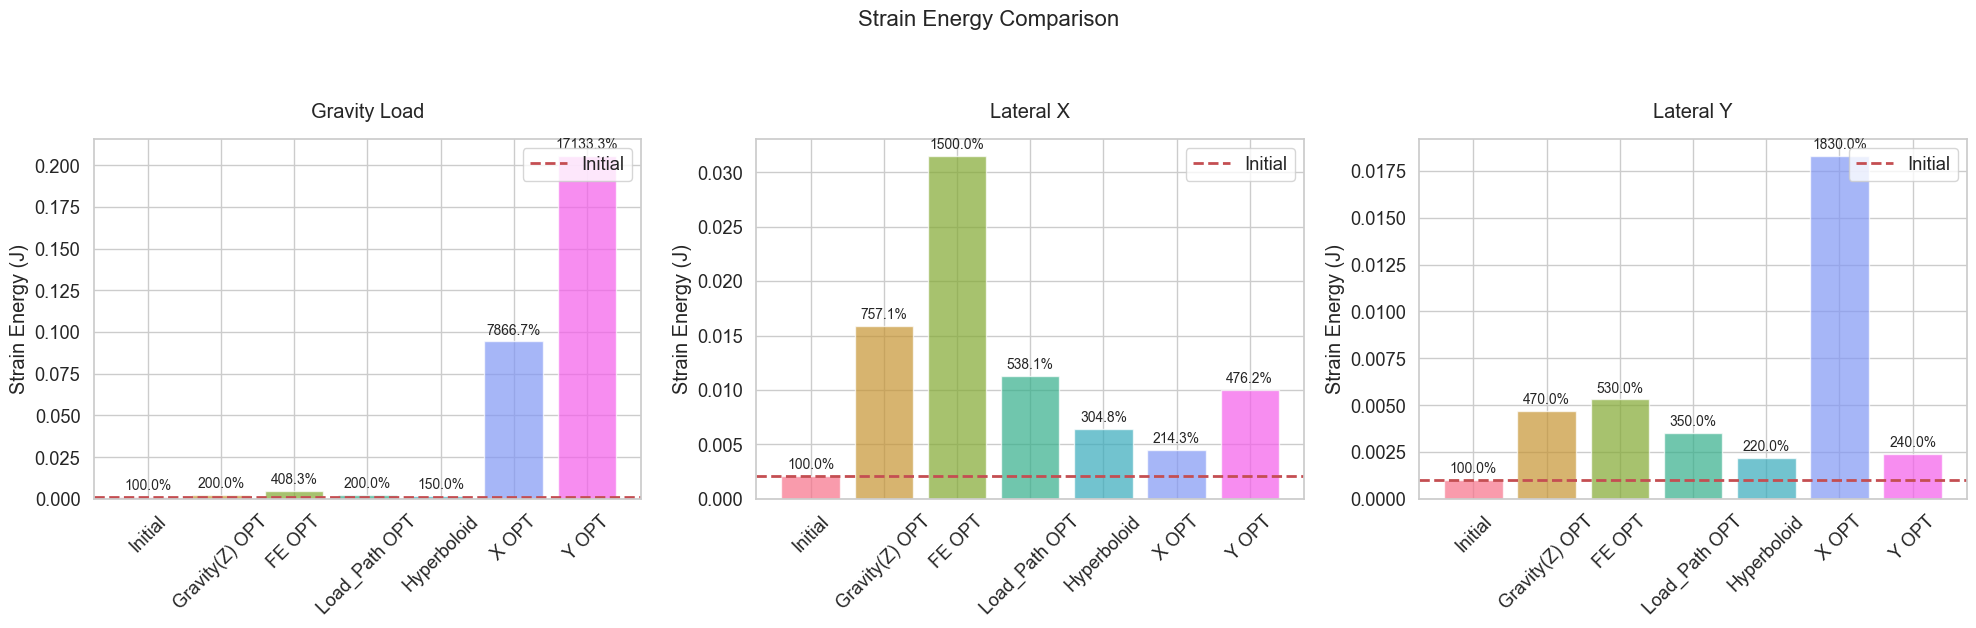

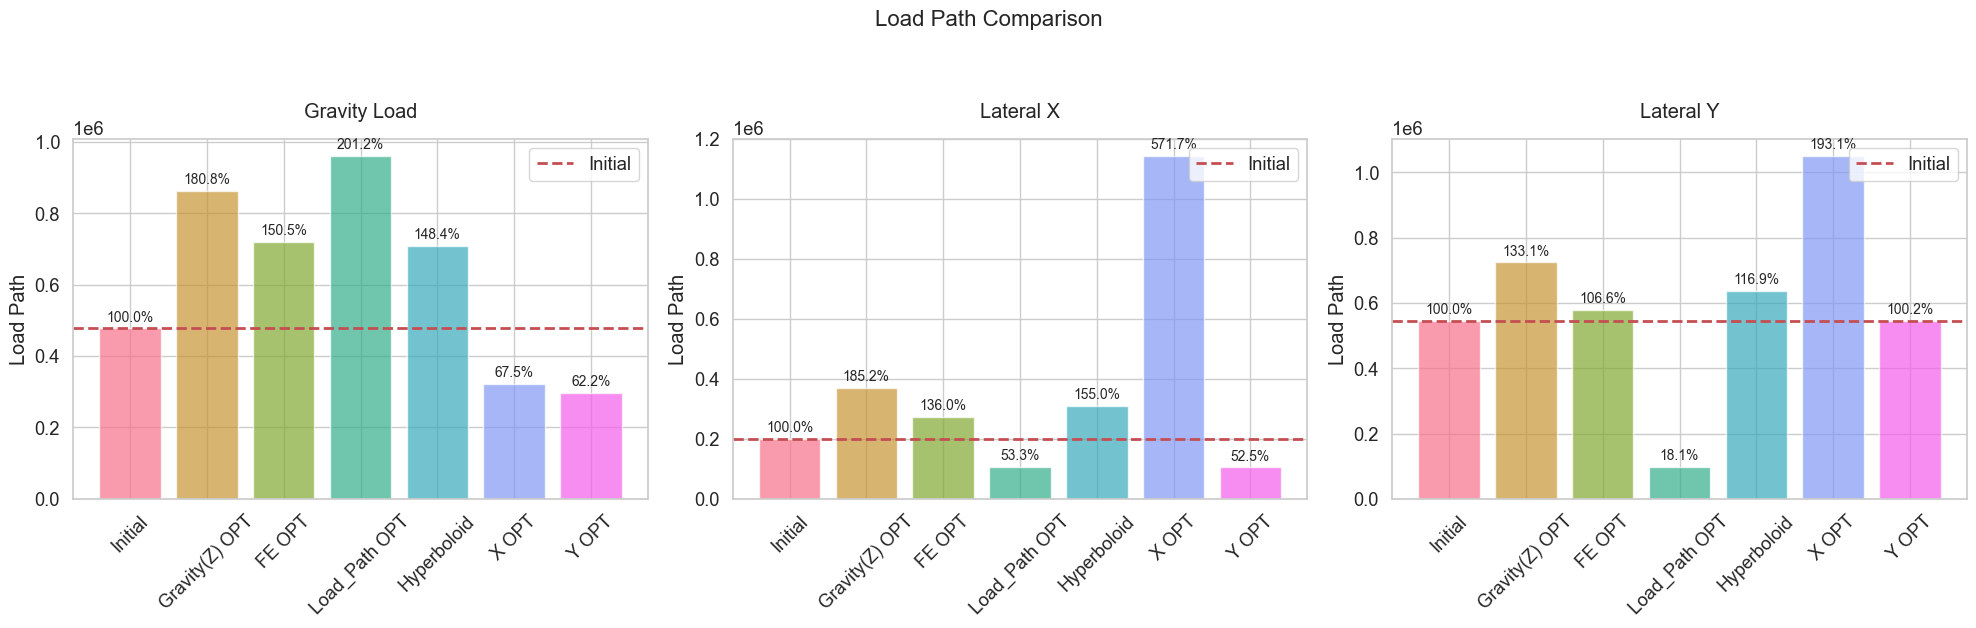

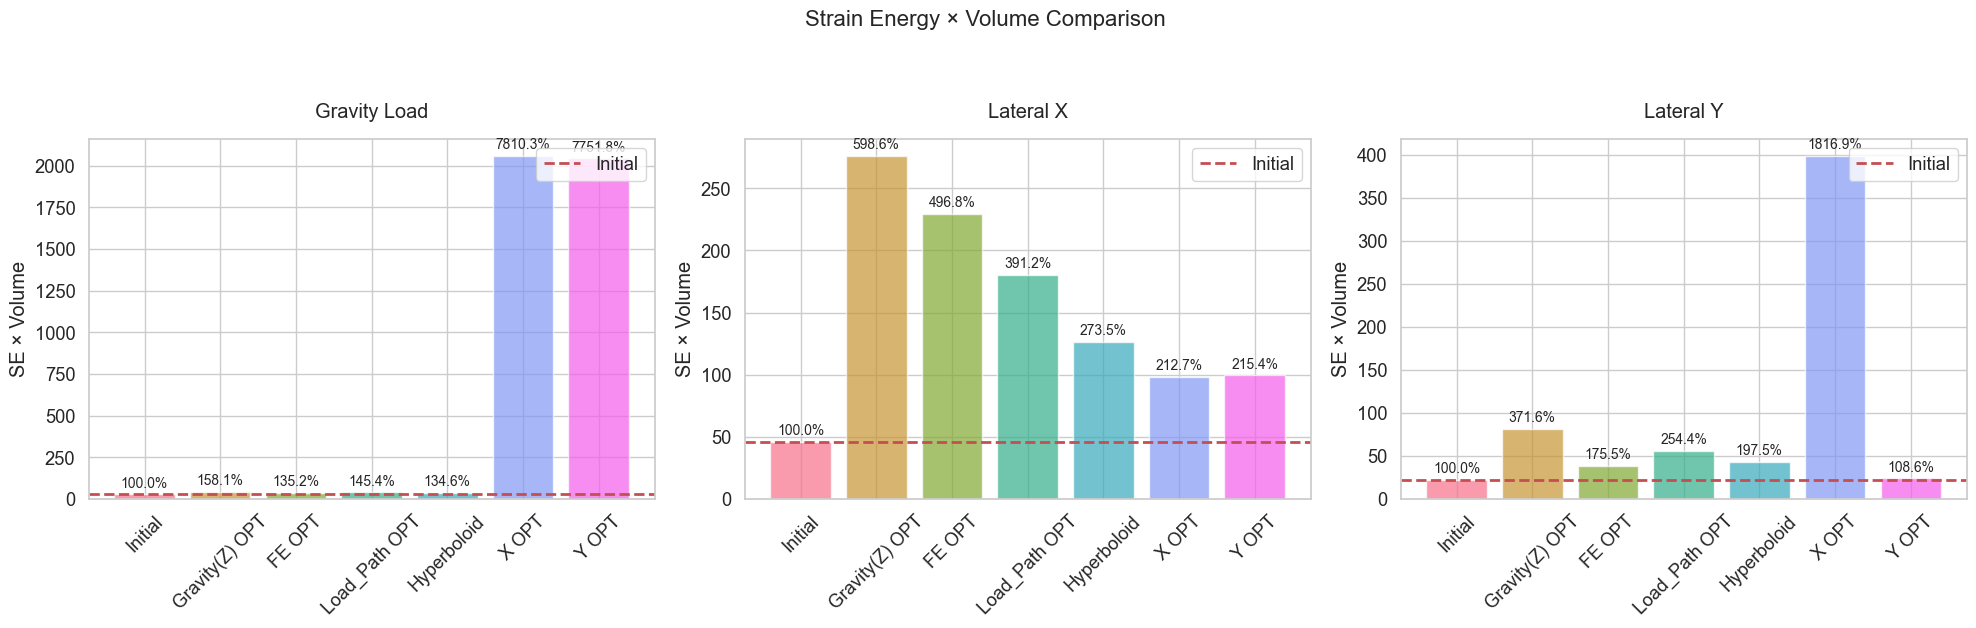

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set Seaborn style
sns.set_theme(style="whitegrid", font_scale=1.2)

# Data - Strain Energy and Volume
data_se = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid","X OPT", "Y OPT"],
    "Gravity_Load": [0.0012, 0.0024, 0.0049, 0.0024, 0.0018, 0.0944,0.2056], 
    "Lateral_X": [0.0021, 0.0159, 0.0315, 0.0113, 0.0064, 0.0045, 0.0100],
    "Lateral_Y": [0.0010, 0.0047, 0.0053, 0.0035, 0.0022, 0.0183, 0.0024],
    "Volume": [21965.8418, 17366.2539, 7275.2100, 15968.5771, 19716.2305, 21808.3984, 9938.2559]
}

# Data - Load Path
data_lp = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid","X OPT","Y OPT"],
    "Gravity_Load": [477363.4062, 863207.0000, 718560.3750, 960317.6250 , 708486.5625, 322185.7500, 297074.3125],
    "Lateral_X": [199955.6562, 370237.3750, 271911.3125, 106634.9219, 309878.3125, 1143239.7500, 105054.67],
    "Lateral_Y": [544122.5000, 724303.6250, 580063.7500, 98522.2969, 636114.6875, 1050897.5000, 545198.7500 ],
    "Volume": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
}

# Convert to DataFrames
df_se = pd.DataFrame(data_se)
df_lp = pd.DataFrame(data_lp)

# Calculate relative improvements (%)
df_se_relative = df_se.copy()
df_lp_relative = df_lp.copy()
df_se_volume_relative = df_se.copy()

for col in ["Gravity_Load", "Lateral_X", "Lateral_Y"]:
    df_se_relative[col] = df_se[col] / df_se[col][0] * 100
    df_lp_relative[col] = df_lp[col] / df_lp[col][0] * 100
    df_se_volume_relative[col] = (df_se[col] * df_se["Volume"]) / (df_se[col][0] * df_se["Volume"][0]) * 100

# Set colors
colors = sns.color_palette("husl", n_colors=len(df_se["Design"]))

# ========== Plot 1: Absolute Strain Energy with Percentage Labels ==========
fig1, axes = plt.subplots(1, 3, figsize=(20, 6))
fig1.suptitle("Strain Energy Comparison", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    bars = axes[i].bar(df_se["Design"], df_se[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("Strain Energy (J)")
    axes[i].axhline(y=df_se[col][0], color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_se_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("u_Strain_Energy.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== Plot 2: Absolute Load Path with Percentage Labels ==========
fig2, axes = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle("Load Path Comparison", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    bars = axes[i].bar(df_lp["Design"], df_lp[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("Load Path")
    axes[i].axhline(y=df_lp[col][0], color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_lp_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("u_Load_Path.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== Plot 3: Absolute SE × Volume with Percentage Labels ==========
fig3, axes = plt.subplots(1, 3, figsize=(20, 6))
fig3.suptitle("Strain Energy × Volume Comparison ", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    # Calculate absolute SE × Volume values
    se_volume = df_se[col] * df_se["Volume"]
    initial_value = se_volume[0]
    
    bars = axes[i].bar(df_se["Design"], se_volume, color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("SE × Volume")
    axes[i].axhline(y=initial_value, color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_se_volume_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("u_SE_Volume.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#################### scaled

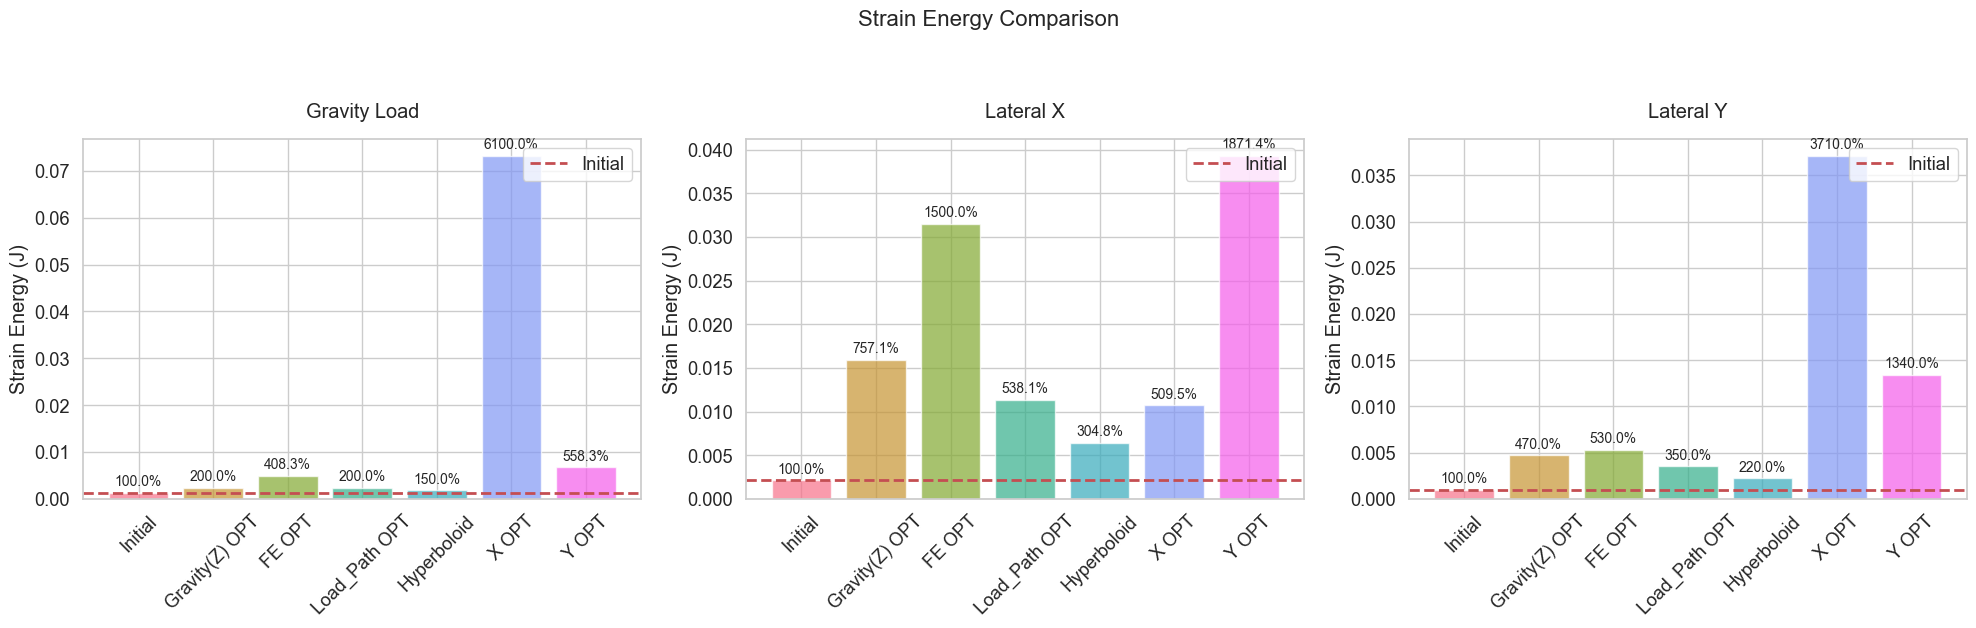

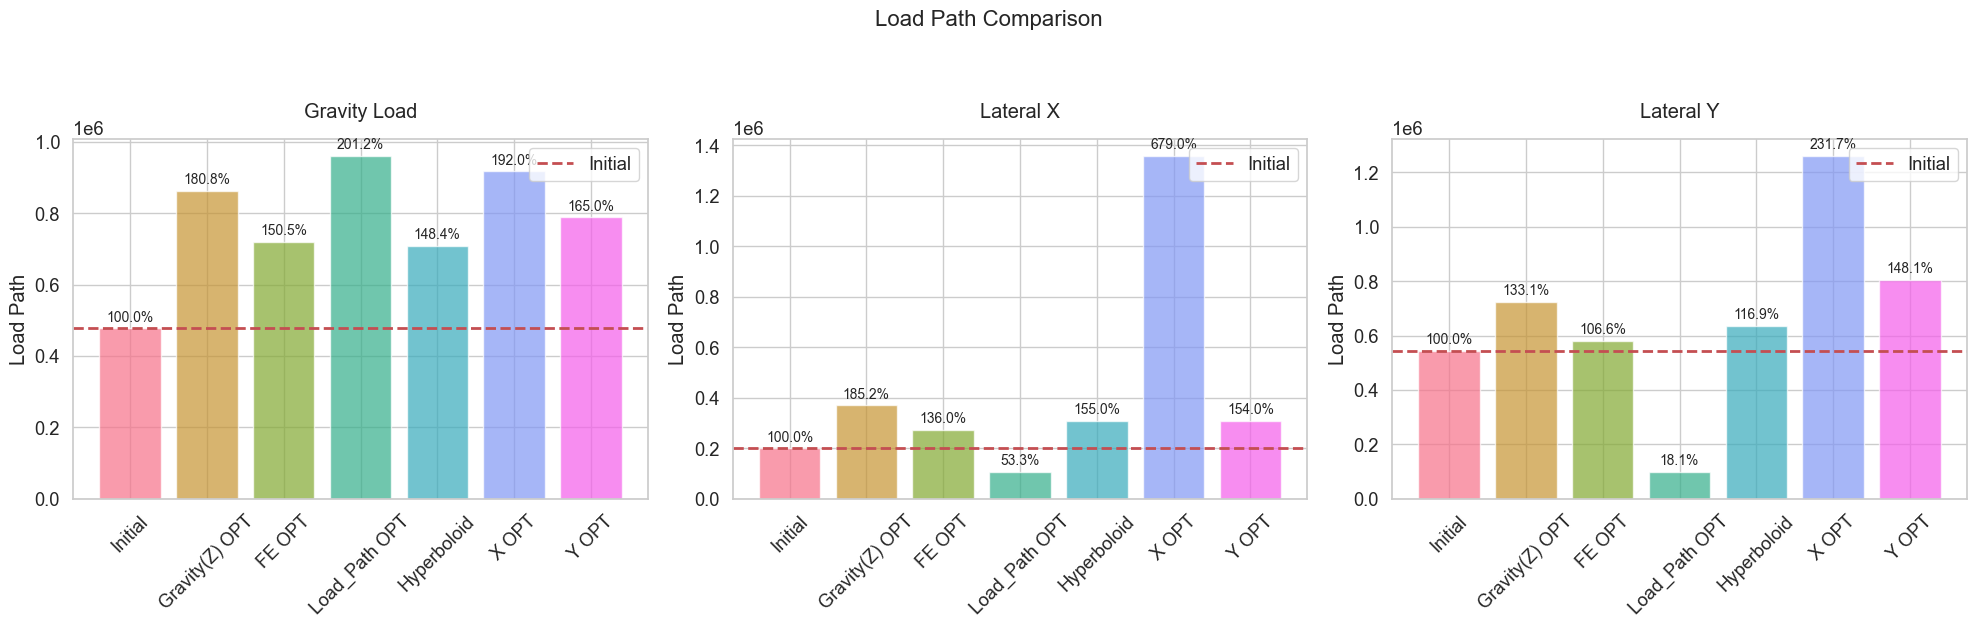

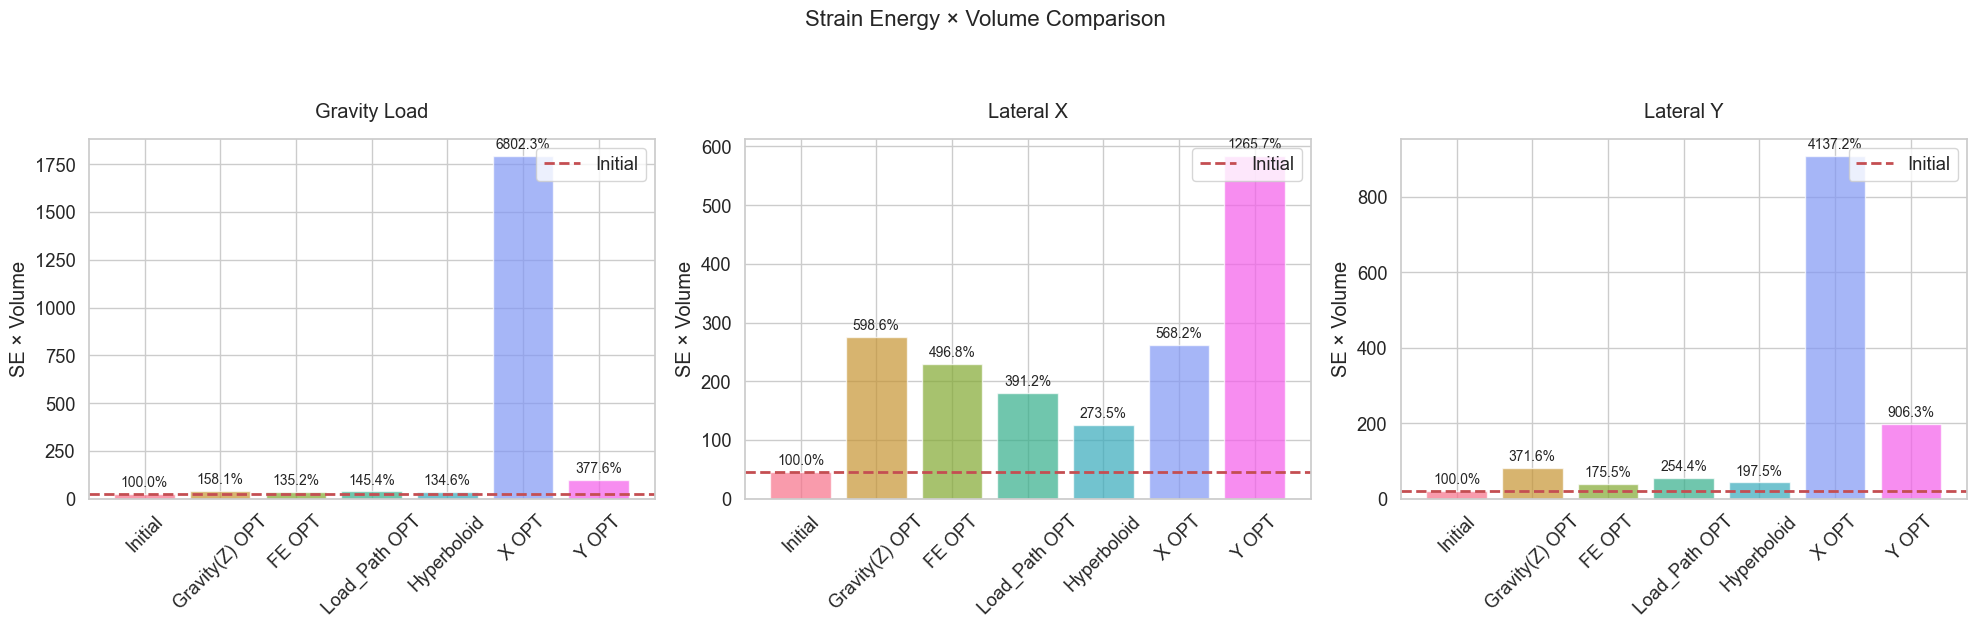

In [2]:
######## Uneven

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set Seaborn style
sns.set_theme(style="whitegrid", font_scale=1.2)

# Data - Strain Energy and Volume
data_se = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid","X OPT", "Y OPT", "Curved grid(Z)"],
    "Gravity_Load": [0.0012, 0.0024, 0.0049, 0.0024, 0.0018, 0.0732,0.0067,0.0648], 
    "Lateral_X": [0.0021, 0.0159, 0.0315, 0.0113, 0.0064, 0.0107, 0.0393],
    "Lateral_Y": [0.0010, 0.0047, 0.0053, 0.0035, 0.0022, 0.0371, 0.0134],
    "Volume": [21965.8418, 17366.2539, 7275.2100, 15968.5771, 19716.2305, 24494.9531, 14856.6406]
}

# Data - Load Path
data_lp = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid","X OPT","Y OPT"],
    "Gravity_Load": [477363.4062, 863207.0000, 718560.3750, 960317.6250 , 708486.5625, 916619.5000, 787877.8125],
    "Lateral_X": [199955.6562, 370237.3750, 271911.3125, 106634.9219, 309878.3125, 1357698.2500, 307929.7188],
    "Lateral_Y": [544122.5000, 724303.6250, 580063.7500, 98522.2969, 636114.6875, 1260997.5000, 805675.3750 ],
    "Volume": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
}

# Convert to DataFrames
df_se = pd.DataFrame(data_se)
df_lp = pd.DataFrame(data_lp)

# Calculate relative improvements (%)
df_se_relative = df_se.copy()
df_lp_relative = df_lp.copy()
df_se_volume_relative = df_se.copy()

for col in ["Gravity_Load", "Lateral_X", "Lateral_Y"]:
    df_se_relative[col] = df_se[col] / df_se[col][0] * 100
    df_lp_relative[col] = df_lp[col] / df_lp[col][0] * 100
    df_se_volume_relative[col] = (df_se[col] * df_se["Volume"]) / (df_se[col][0] * df_se["Volume"][0]) * 100

# Set colors
colors = sns.color_palette("husl", n_colors=len(df_se["Design"]))

# ========== Plot 1: Absolute Strain Energy with Percentage Labels ==========
fig1, axes = plt.subplots(1, 3, figsize=(20, 6))
fig1.suptitle("Strain Energy Comparison", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    bars = axes[i].bar(df_se["Design"], df_se[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("Strain Energy (J)")
    axes[i].axhline(y=df_se[col][0], color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_se_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("u_Strain_Energy.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== Plot 2: Absolute Load Path with Percentage Labels ==========
fig2, axes = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle("Load Path Comparison", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    bars = axes[i].bar(df_lp["Design"], df_lp[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("Load Path")
    axes[i].axhline(y=df_lp[col][0], color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_lp_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("u_Load_Path.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== Plot 3: Absolute SE × Volume with Percentage Labels ==========
fig3, axes = plt.subplots(1, 3, figsize=(20, 6))
fig3.suptitle("Strain Energy × Volume Comparison ", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    # Calculate absolute SE × Volume values
    se_volume = df_se[col] * df_se["Volume"]
    initial_value = se_volume[0]
    
    bars = axes[i].bar(df_se["Design"], se_volume, color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("SE × Volume")
    axes[i].axhline(y=initial_value, color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_se_volume_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("u_SE_Volume.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#### Curved_OPT

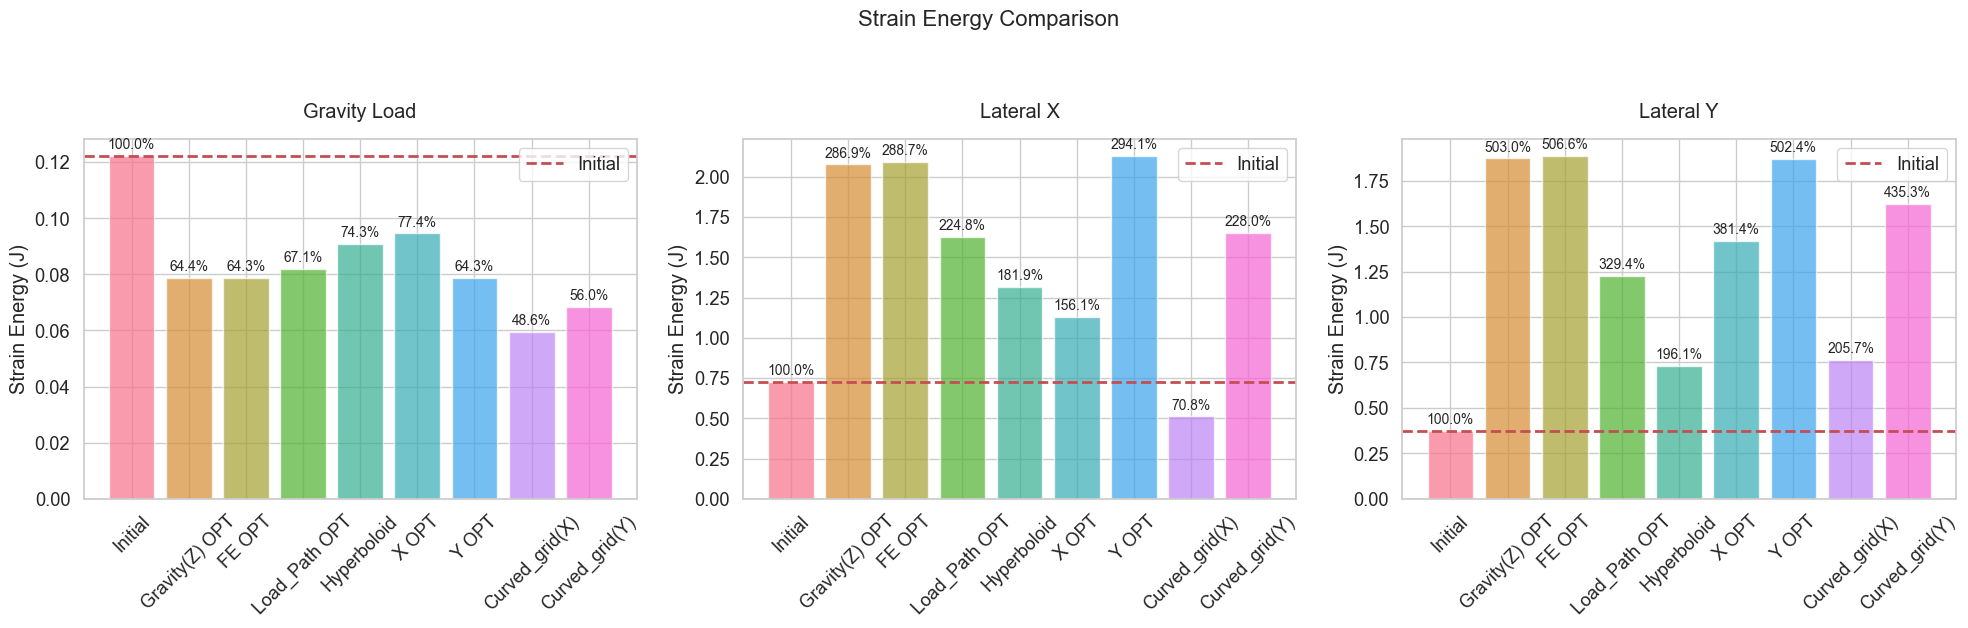

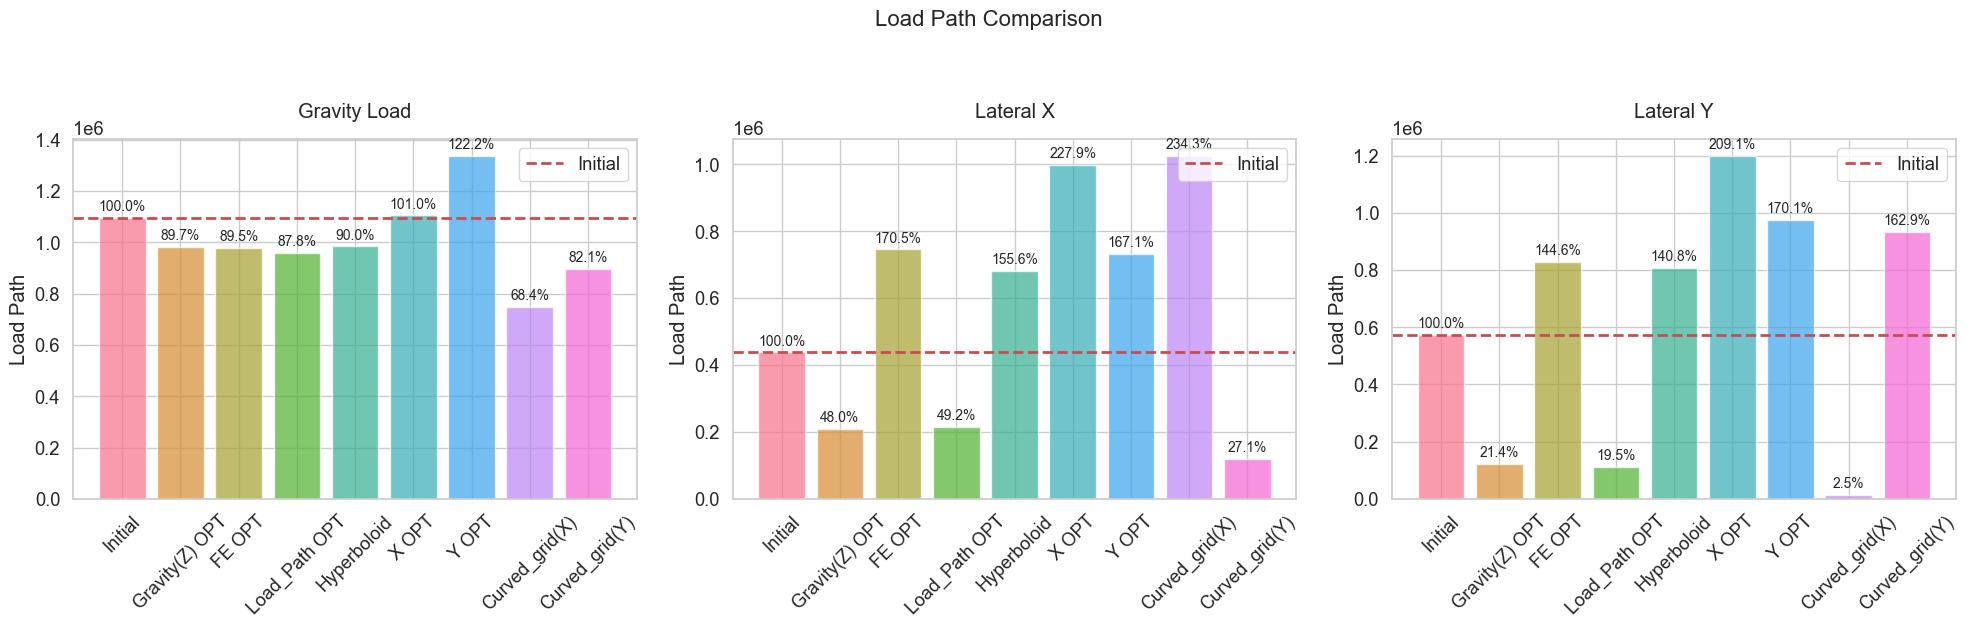

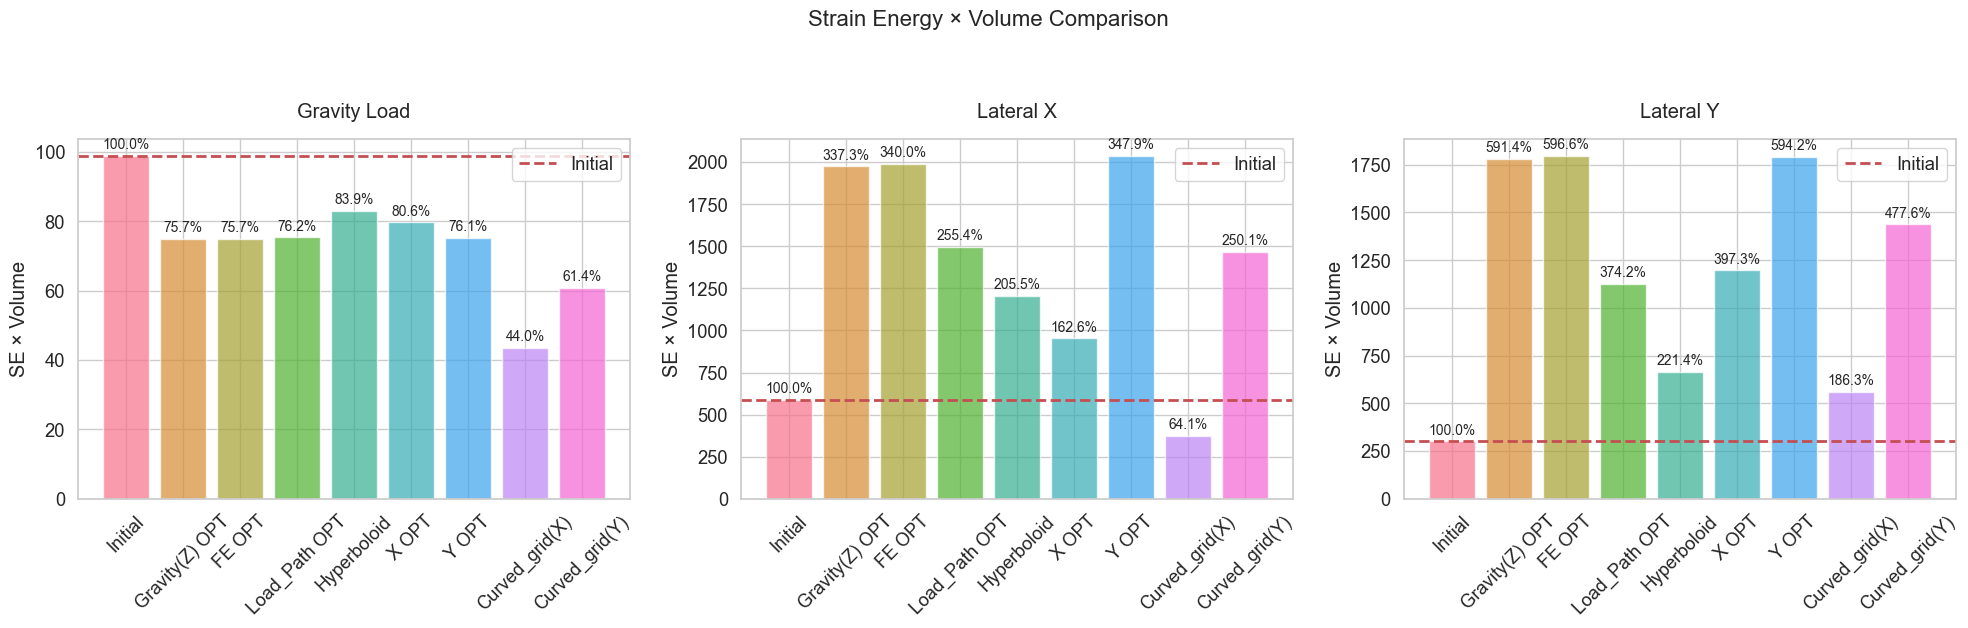

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set Seaborn style
sns.set_theme(style="whitegrid", font_scale=1.2)

# Data - Strain Energy and Volume
data_se = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid","X OPT", "Y OPT", "Curved_grid(X)", "Curved_grid(Y)"],
    "Gravity_Load": [0.1222, 0.0787, 0.0786, 0.0820, 0.0908, 0.0946, 0.0786, 0.0594,0.0684], 
    "Lateral_X": [0.7242, 2.0775, 2.0911, 1.6279, 1.3176, 1.1308, 2.1302,0.5124, 1.6509],
    "Lateral_Y": [0.3724, 1.8730, 1.8866 , 1.2266, 0.7302, 1.4204, 1.8711, 0.7662,1.6212],
    "Volume": [808.5354, 950.7169, 952.1912, 918.5100, 913.0774, 842.1284, 956.2022,732.1449,887.0209]
}

# Data - Load Path
data_lp = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid","X OPT", "Y OPT", "Curved_grid(X)", "Curved_grid(Y)"],
    "Gravity_Load": [1094050.2500, 981475.8125, 978795.1250, 960317.6250, 984655.5000, 1105444.6250, 1337246.5000,747860.5000,898043.2500],
    "Lateral_X": [437452.8750, 209818.5625, 745746.0625, 215403.4375, 680823.6250, 996862.1250 , 731129.1875,1024844.1875,118501.9531],
    "Lateral_Y": [573551.6875, 122979.0938, 829127.6250, 111596.7188, 807425.8750, 1199335., 975580.0625,14603.7109,934415.7500],
    "Volume": [1.0, 1.0, 1.0, 1.0, 1.0, 0, 1.0, 1.0,1.0]
}


# Convert to DataFrames
df_se = pd.DataFrame(data_se)
df_lp = pd.DataFrame(data_lp)

# Calculate relative improvements (%)
df_se_relative = df_se.copy()
df_lp_relative = df_lp.copy()
df_se_volume_relative = df_se.copy()

for col in ["Gravity_Load", "Lateral_X", "Lateral_Y"]:
    df_se_relative[col] = df_se[col] / df_se[col][0] * 100
    df_lp_relative[col] = df_lp[col] / df_lp[col][0] * 100
    df_se_volume_relative[col] = (df_se[col] * df_se["Volume"]) / (df_se[col][0] * df_se["Volume"][0]) * 100

# Set colors
colors = sns.color_palette("husl", n_colors=len(df_se["Design"]))

# ========== Plot 1: Absolute Strain Energy with Percentage Labels ==========
fig1, axes = plt.subplots(1, 3, figsize=(20, 6))
fig1.suptitle("Strain Energy Comparison", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    bars = axes[i].bar(df_se["Design"], df_se[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("Strain Energy (J)")
    axes[i].axhline(y=df_se[col][0], color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_se_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("e_Strain_Energy.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== Plot 2: Absolute Load Path with Percentage Labels ==========
fig2, axes = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle("Load Path Comparison", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    bars = axes[i].bar(df_lp["Design"], df_lp[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("Load Path")
    axes[i].axhline(y=df_lp[col][0], color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_lp_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("e_Load_Path.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== Plot 3: Absolute SE × Volume with Percentage Labels ==========
fig3, axes = plt.subplots(1, 3, figsize=(20, 6))
fig3.suptitle("Strain Energy × Volume Comparison", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    # Calculate absolute SE × Volume values
    se_volume = df_se[col] * df_se["Volume"]
    initial_value = se_volume[0]
    
    bars = axes[i].bar(df_se["Design"], se_volume, color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("SE × Volume")
    axes[i].axhline(y=initial_value, color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_se_volume_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("e_SE_Volume.png", dpi=300, bbox_inches='tight')
plt.show()

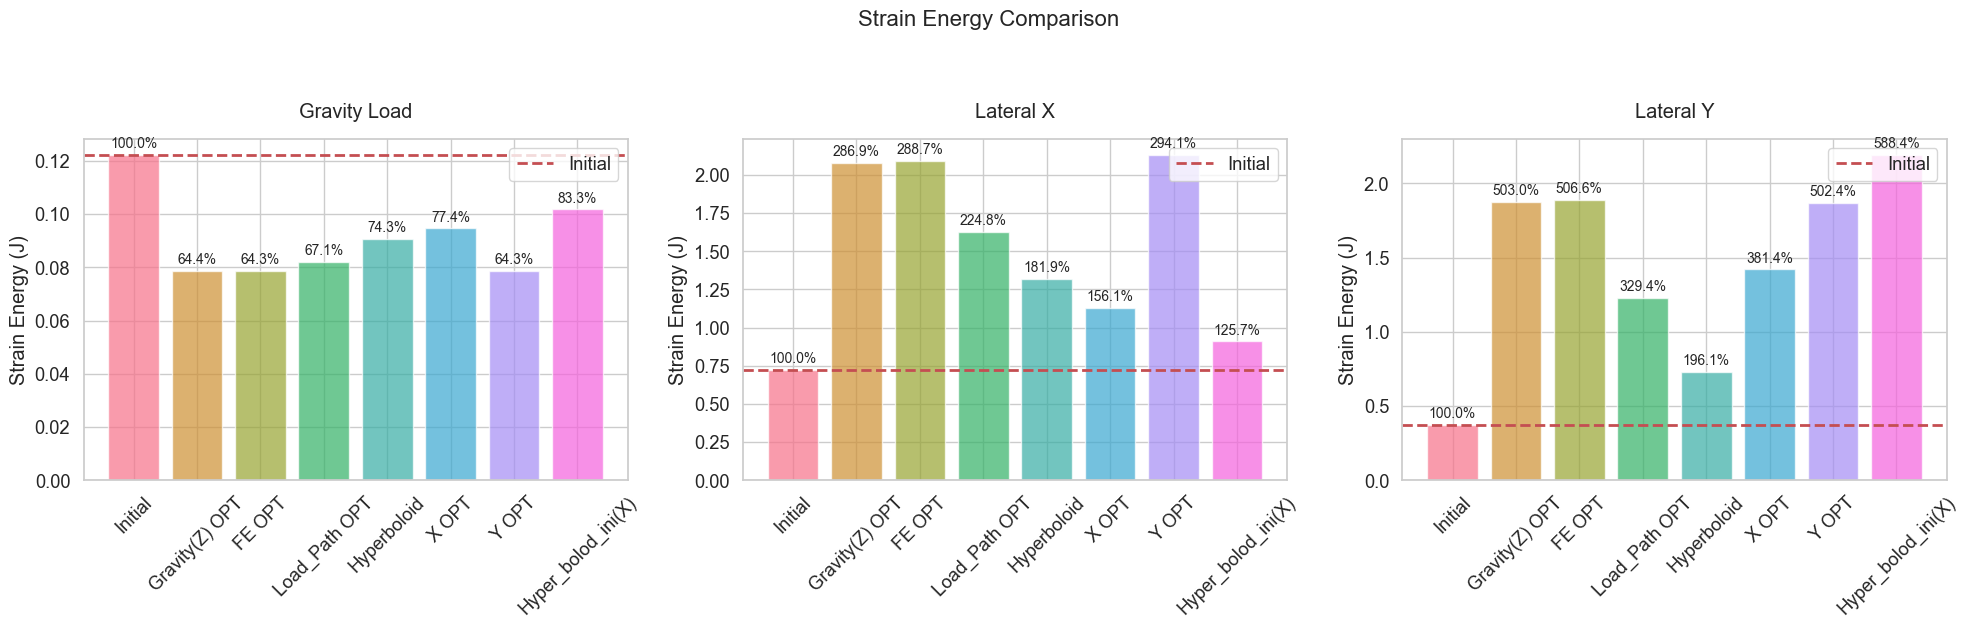

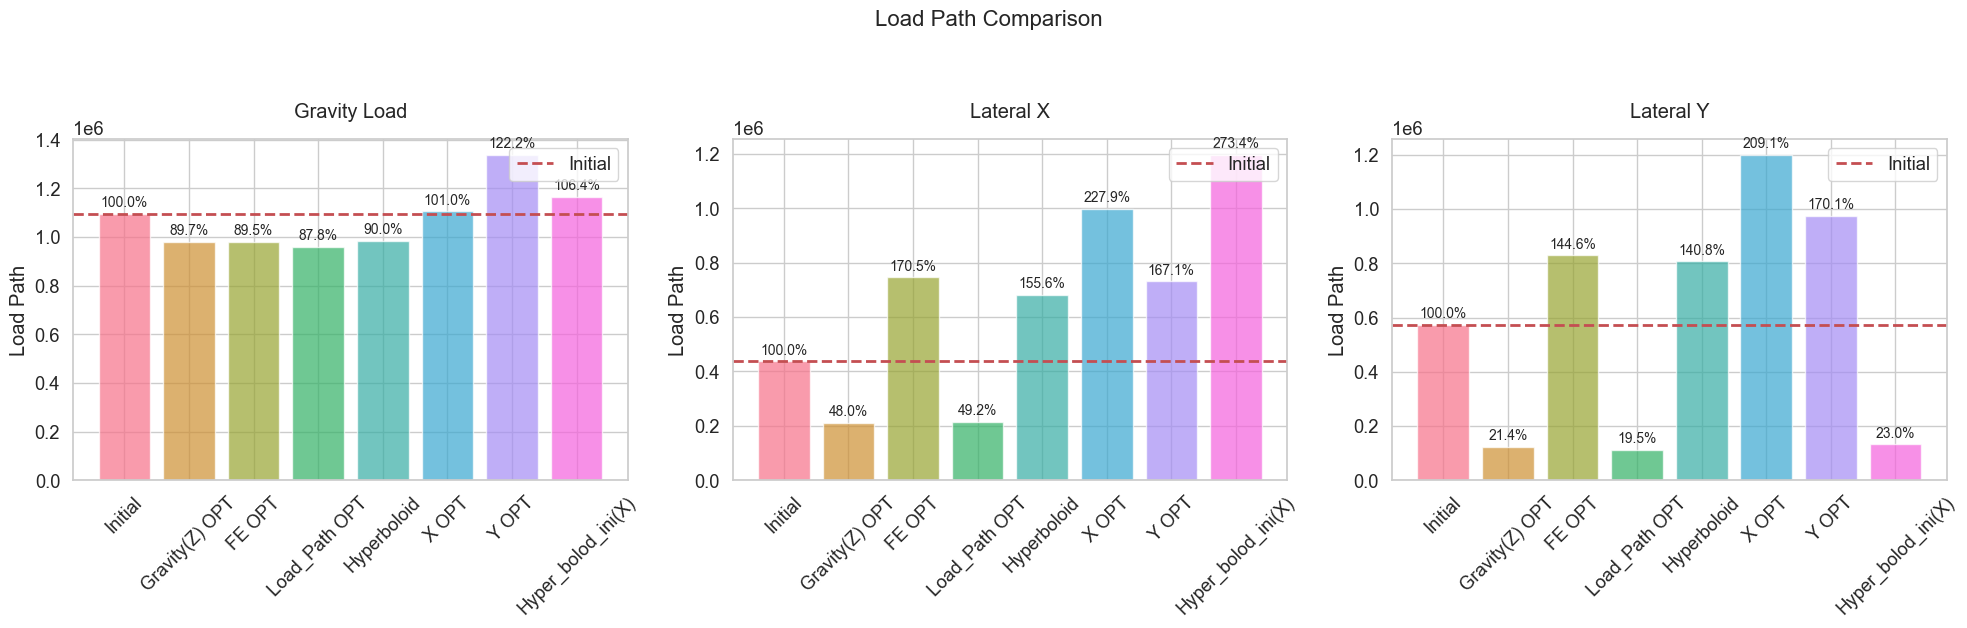

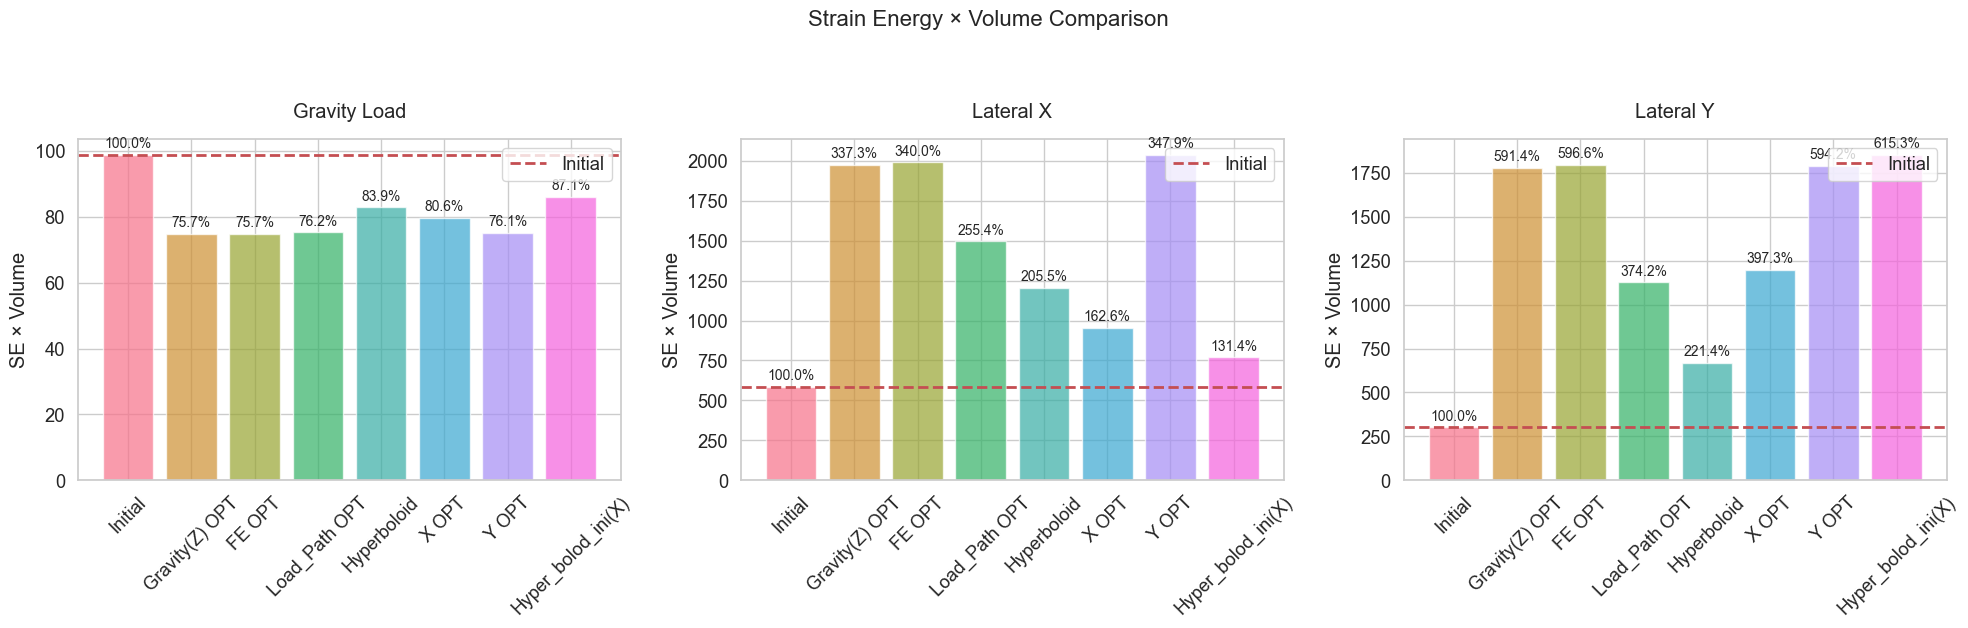

In [6]:
## Hyper bolid (scaling)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set Seaborn style
sns.set_theme(style="whitegrid", font_scale=1.2)

# Data - Strain Energy and Volume
data_se = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid","X OPT", "Y OPT", "Hyper_bolod_ini(X)"],
    "Gravity_Load": [0.1222, 0.0787, 0.0786, 0.0820, 0.0908, 0.0946, 0.0786, 0.1018], 
    "Lateral_X": [0.7242, 2.0775, 2.0911, 1.6279, 1.3176, 1.1308, 2.1302, 0.9100],
    "Lateral_Y": [0.3724, 1.8730, 1.8866 , 1.2266, 0.7302, 1.4204, 1.8711, 2.1912],
    "Volume": [808.5354, 950.7169, 952.1912, 918.5100, 913.0774, 842.1284, 956.2022,845.5346]
}

# Data - Load Path
data_lp = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid","X OPT", "Y OPT", "Hyper_bolod_ini(X)"],
    "Gravity_Load": [1094050.2500, 981475.8125, 978795.1250, 960317.6250, 984655.5000, 1105444.6250, 1337246.5000, 1163660.3750],
    "Lateral_X": [437452.8750, 209818.5625, 745746.0625, 215403.4375, 680823.6250, 996862.1250 ,731129.1875, 1196076.2500],
    "Lateral_Y": [573551.6875, 122979.0938, 829127.6250, 111596.7188, 807425.8750, 1199335., 975580.0625, 131914.7812],
    "Volume": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
}


# Convert to DataFrames
df_se = pd.DataFrame(data_se)
df_lp = pd.DataFrame(data_lp)

# Calculate relative improvements (%)
df_se_relative = df_se.copy()
df_lp_relative = df_lp.copy()
df_se_volume_relative = df_se.copy()

for col in ["Gravity_Load", "Lateral_X", "Lateral_Y"]:
    df_se_relative[col] = df_se[col] / df_se[col][0] * 100
    df_lp_relative[col] = df_lp[col] / df_lp[col][0] * 100
    df_se_volume_relative[col] = (df_se[col] * df_se["Volume"]) / (df_se[col][0] * df_se["Volume"][0]) * 100

# Set colors
colors = sns.color_palette("husl", n_colors=len(df_se["Design"]))

# ========== Plot 1: Absolute Strain Energy with Percentage Labels ==========
fig1, axes = plt.subplots(1, 3, figsize=(20, 6))
fig1.suptitle("Strain Energy Comparison", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    bars = axes[i].bar(df_se["Design"], df_se[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("Strain Energy (J)")
    axes[i].axhline(y=df_se[col][0], color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_se_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("e_Strain_Energy.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== Plot 2: Absolute Load Path with Percentage Labels ==========
fig2, axes = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle("Load Path Comparison", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    bars = axes[i].bar(df_lp["Design"], df_lp[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("Load Path")
    axes[i].axhline(y=df_lp[col][0], color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_lp_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("e_Load_Path.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== Plot 3: Absolute SE × Volume with Percentage Labels ==========
fig3, axes = plt.subplots(1, 3, figsize=(20, 6))
fig3.suptitle("Strain Energy × Volume Comparison", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    # Calculate absolute SE × Volume values
    se_volume = df_se[col] * df_se["Volume"]
    initial_value = se_volume[0]
    
    bars = axes[i].bar(df_se["Design"], se_volume, color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("SE × Volume")
    axes[i].axhline(y=initial_value, color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_se_volume_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("e_SE_Volume.png", dpi=300, bbox_inches='tight')
plt.show()




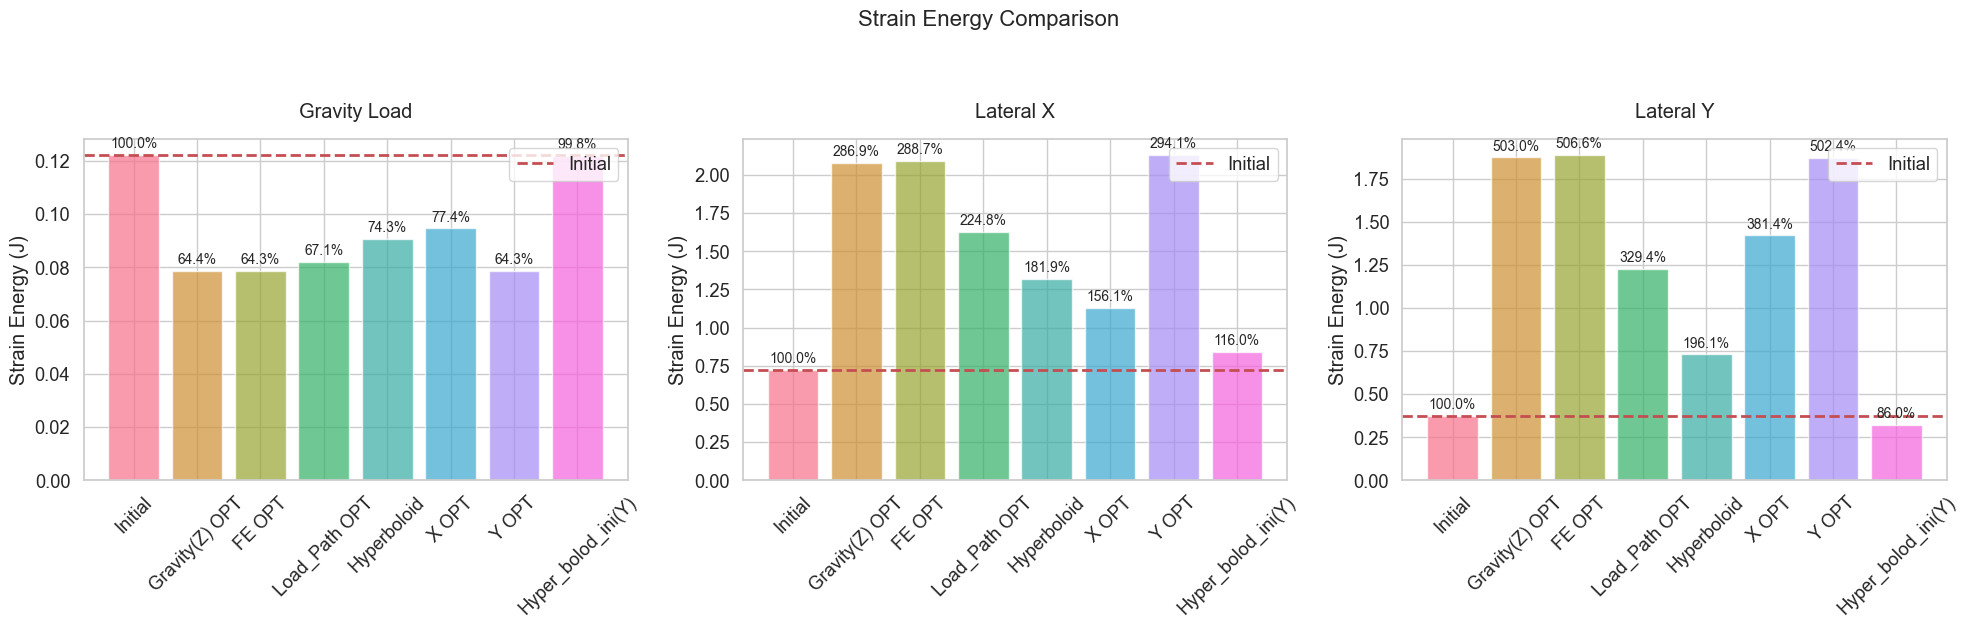

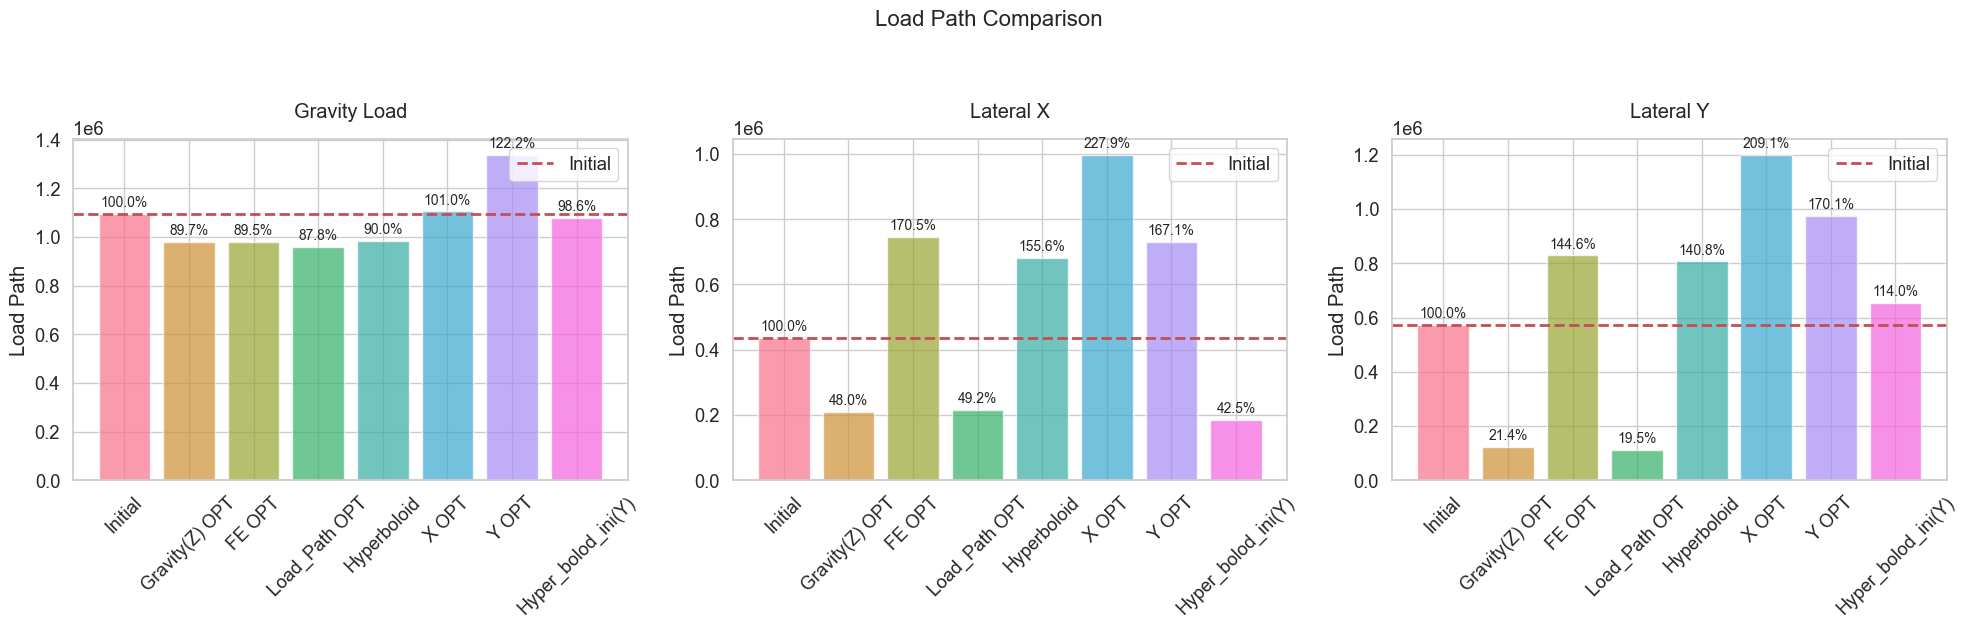

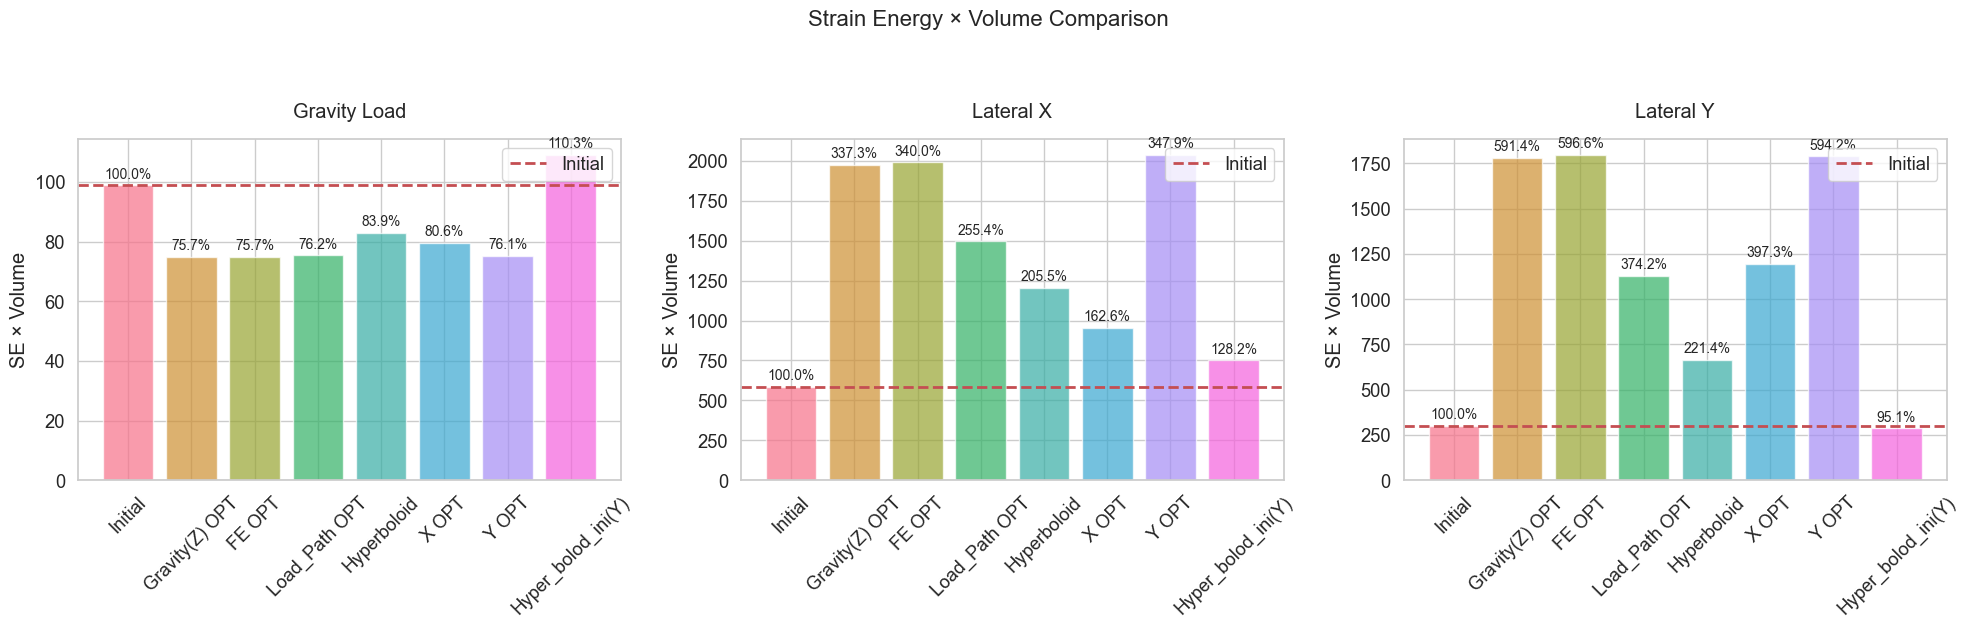

In [8]:
## Hyper bolid (scaling)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set Seaborn style
sns.set_theme(style="whitegrid", font_scale=1.2)

# Data - Strain Energy and Volume
data_se = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid","X OPT", "Y OPT", "Hyper_bolod_ini(Y)"],
    "Gravity_Load": [0.1222, 0.0787, 0.0786, 0.0820, 0.0908, 0.0946, 0.0786, 0.1219], 
    "Lateral_X": [0.7242, 2.0775, 2.0911, 1.6279, 1.3176, 1.1308, 2.1302, 0.8398],
    "Lateral_Y": [0.3724, 1.8730, 1.8866 , 1.2266, 0.7302, 1.4204, 1.8711, 0.3202],
    "Volume": [808.5354, 950.7169, 952.1912, 918.5100, 913.0774, 842.1284, 956.2022,894.1045]
}

# Data - Load Path
data_lp = {
    "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid","X OPT", "Y OPT", "Hyper_bolod_ini(Y)"],
    "Gravity_Load": [1094050.2500, 981475.8125, 978795.1250, 960317.6250, 984655.5000, 1105444.6250, 1337246.5000, 1078825.1250],
    "Lateral_X": [437452.8750, 209818.5625, 745746.0625, 215403.4375, 680823.6250, 996862.1250 ,731129.1875, 185708.4688],
    "Lateral_Y": [573551.6875, 122979.0938, 829127.6250, 111596.7188, 807425.8750, 1199335., 975580.0625, 653956.4375],
    "Volume": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
}


# Convert to DataFrames
df_se = pd.DataFrame(data_se)
df_lp = pd.DataFrame(data_lp)

# Calculate relative improvements (%)
df_se_relative = df_se.copy()
df_lp_relative = df_lp.copy()
df_se_volume_relative = df_se.copy()

for col in ["Gravity_Load", "Lateral_X", "Lateral_Y"]:
    df_se_relative[col] = df_se[col] / df_se[col][0] * 100
    df_lp_relative[col] = df_lp[col] / df_lp[col][0] * 100
    df_se_volume_relative[col] = (df_se[col] * df_se["Volume"]) / (df_se[col][0] * df_se["Volume"][0]) * 100

# Set colors
colors = sns.color_palette("husl", n_colors=len(df_se["Design"]))

# ========== Plot 1: Absolute Strain Energy with Percentage Labels ==========
fig1, axes = plt.subplots(1, 3, figsize=(20, 6))
fig1.suptitle("Strain Energy Comparison", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    bars = axes[i].bar(df_se["Design"], df_se[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("Strain Energy (J)")
    axes[i].axhline(y=df_se[col][0], color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_se_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("e_Strain_Energy.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== Plot 2: Absolute Load Path with Percentage Labels ==========
fig2, axes = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle("Load Path Comparison", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    bars = axes[i].bar(df_lp["Design"], df_lp[col], color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("Load Path")
    axes[i].axhline(y=df_lp[col][0], color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_lp_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("e_Load_Path.png", dpi=300, bbox_inches='tight')
plt.show()

# ========== Plot 3: Absolute SE × Volume with Percentage Labels ==========
fig3, axes = plt.subplots(1, 3, figsize=(20, 6))
fig3.suptitle("Strain Energy × Volume Comparison", fontsize=16, y=1.05)

for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
    # Calculate absolute SE × Volume values
    se_volume = df_se[col] * df_se["Volume"]
    initial_value = se_volume[0]
    
    bars = axes[i].bar(df_se["Design"], se_volume, color=colors, alpha=0.7)
    axes[i].set_title(col.replace("_", " "), pad=15)
    axes[i].set_ylabel("SE × Volume")
    axes[i].axhline(y=initial_value, color='r', linestyle='--', linewidth=2, label="Initial")
    axes[i].legend(loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add percentage labels
    axes[i].bar_label(
        bars, 
        labels=[f"{val:.1f}%" for val in df_se_volume_relative[col]],
        padding=3,
        fontsize=10
    )

plt.tight_layout()
plt.savefig("e_SE_Volume.png", dpi=300, bbox_inches='tight')
plt.show()




In [ ]:
# ################ Uneven

# import numpy as np
# import matplotlib.pyplot as plt
# import pandas as pd
# import seaborn as sns

# # Set Seaborn style
# sns.set_theme(style="whitegrid", font_scale=1.2)

# # Data - Strain Energy and Volume
# data_se = {
#     "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid","X OPT", "Y OPT"],
#     "Gravity_Load": [0.0012, 0.0024, 0.0049, 0.0024, 0.0018, 0.0944,0.2056], 
#     "Lateral_X": [0.0021, 0.0159, 0.0315, 0.0113, 0.0064, 0.0045, 0.0100],
#     "Lateral_Y": [0.0010, 0.0047, 0.0053, 0.0035, 0.0022, 0.0183, 0.0024],
#     "Volume": [21965.8418, 17366.2539, 7275.2100, 15968.5771, 19716.2305, 21808.3984, 9938.2559]  # Added Volume data
# }

# # Data - Load Path
# data_lp = {
#     "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid","X OPT","Y OPT"],
#     "Gravity_Load": [477363.4062, 863207.0000, 718560.3750, 960317.6250 , 708486.5625, 322185.7500, 297074.3125],
#     "Lateral_X": [199955.6562, 370237.3750, 271911.3125, 106634.9219, 309878.3125, 1143239.7500, 105054.67],
#     "Lateral_Y": [544122.5000, 724303.6250, 580063.7500, 98522.2969, 636114.6875, 1050897.5000, 545198.7500 ],
#     "Volume": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]  # Added Volume data
# }

# # Convert to DataFrames
# df_se = pd.DataFrame(data_se)
# df_lp = pd.DataFrame(data_lp)

# # Calculate relative improvements (%)
# df_se_relative = df_se.copy()
# df_lp_relative = df_lp.copy()
# df_se_volume_relative = df_se.copy()  # For SE * Volume comparison

# for col in ["Gravity_Load", "Lateral_X", "Lateral_Y"]:
#     df_se_relative[col] = df_se[col] / df_se[col][0] * 100
#     df_lp_relative[col] = df_lp[col] / df_lp[col][0] * 100
#     # Calculate SE * Volume relative to initial
#     df_se_volume_relative[col] = (df_se[col] * df_se["Volume"]) / (df_se[col][0] * df_se["Volume"][0]) * 100

# # Set colors
# colors = sns.color_palette("husl", n_colors=len(df_se["Design"]))

# # ========== Plot 1: Relative Strain Energy ==========
# fig1, axes = plt.subplots(1, 3, figsize=(20, 6))
# fig1.suptitle("Strain Energy Comparison (Relative to Initial Design)", fontsize=16, y=1.05)

# for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
#     bars = axes[i].bar(df_se["Design"], df_se_relative[col], color=colors, alpha=0.7)
#     axes[i].set_title(col.replace("_", " "), pad=15)
#     axes[i].set_ylabel("Strain Energy (% of Initial)")
#     axes[i].axhline(y=100, color='r', linestyle='--', linewidth=2, label="Baseline (100%)")
#     axes[i].legend(loc='upper right')
#     axes[i].tick_params(axis='x', rotation=45)
    
#     axes[i].bar_label(
#         bars, 
#         labels=[f"{val:.1f}%" for val in df_se_relative[col]],
#         padding=3,
#         fontsize=10
#     )

# plt.tight_layout()
# plt.savefig("Strain_Energy_Relative.png", dpi=300, bbox_inches='tight')
# plt.show()

# # ========== Plot 2: Relative Load Path ==========
# fig2, axes = plt.subplots(1, 3, figsize=(20, 6))
# fig2.suptitle("Load Path Comparison (Relative to Initial Design)", fontsize=16, y=1.05)

# for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
#     bars = axes[i].bar(df_lp["Design"], df_lp_relative[col], color=colors, alpha=0.7)
#     axes[i].set_title(col.replace("_", " "), pad=15)
#     axes[i].set_ylabel("Load Path (% of Initial)")
#     axes[i].axhline(y=100, color='r', linestyle='--', linewidth=2, label="Baseline (100%)")
#     axes[i].legend(loc='upper right')
#     axes[i].tick_params(axis='x', rotation=45)
    
#     axes[i].bar_label(
#         bars, 
#         labels=[f"{val:.1f}%" for val in df_lp_relative[col]],
#         padding=3,
#         fontsize=10
#     )

# plt.tight_layout()
# plt.savefig("Load_Path_Relative.png", dpi=300, bbox_inches='tight')
# plt.show()

# # ========== Plot 3: Strain Energy * Volume Relative ==========
# fig3, axes = plt.subplots(1, 3, figsize=(20, 6))
# fig3.suptitle("Strain Energy × Volume Comparison (Relative to Initial Design)", fontsize=16, y=1.05)

# for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
#     bars = axes[i].bar(df_se["Design"], df_se_volume_relative[col], color=colors, alpha=0.7)
#     axes[i].set_title(col.replace("_", " "), pad=15)
#     axes[i].set_ylabel("SE × Volume (% of Initial)")
#     axes[i].axhline(y=100, color='r', linestyle='--', linewidth=2, label="Baseline (100%)")
#     axes[i].legend(loc='upper right')
#     axes[i].tick_params(axis='x', rotation=45)
    
#     axes[i].bar_label(
#         bars, 
#         labels=[f"{val:.1f}%" for val in df_se_volume_relative[col]],
#         padding=3,
#         fontsize=10
#     )

# plt.tight_layout()
# plt.savefig("SE_Volume_Relative.png", dpi=300, bbox_inches='tight')
# plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import pandas as pd
# import seaborn as sns

# # Set Seaborn style
# sns.set_theme(style="whitegrid", font_scale=1.2)

# # Data - Strain Energy and Volume
# data_se = {
#     "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid","X OPT", "Y OPT"],
#     "Gravity_Load": [0.1222, 0.0787, 0.0786, 0.0820, 0.0908, 0.2158, 0.2056], 
#     "Lateral_X": [0.7242, 2.0775, 2.0911, 1.6279, 1.3176, 0.4369, 0.4884],
#     "Lateral_Y": [0.3724, 1.8730, 1.8866 , 1.2266, 0.7302, 0.2473, 0.1609],
#     "Volume": [808.5354, 950.7169, 952.1912, 918.5100, 913.0774, 706.0973, 779.3370]  # Added Volume data
# }

# # Data - Load Path
# data_lp = {
#     "Design": ["Initial", "Gravity(Z) OPT", "FE OPT", "Load_Path OPT", "Hyperboloid","X OPT", "Y OPT"],
#     "Gravity_Load": [1094050.2500, 981475.8125, 978795.1250, 960317.6250, 984655.5000, 1491904.7500, 1337246.5000],
#     "Lateral_X": [437452.8750, 209818.5625, 745746.0625, 215403.4375, 680823.6250, 589404.0 , 146582.9375],
#     "Lateral_Y": [573551.6875, 122979.0938, 829127.6250, 111596.7188, 807425.8750, 39605.6719, 501817.5625],
#     "Volume": [1.0, 1.0, 1.0, 1.0, 1.0, 0, 1.0]  # Added Volume data
# }

# # Convert to DataFrames
# df_se = pd.DataFrame(data_se)
# df_lp = pd.DataFrame(data_lp)

# # Calculate relative improvements (%)
# df_se_relative = df_se.copy()
# df_lp_relative = df_lp.copy()
# df_se_volume_relative = df_se.copy()  # For SE * Volume comparison

# for col in ["Gravity_Load", "Lateral_X", "Lateral_Y"]:
#     df_se_relative[col] = df_se[col] / df_se[col][0] * 100
#     df_lp_relative[col] = df_lp[col] / df_lp[col][0] * 100
#     # Calculate SE * Volume relative to initial
#     df_se_volume_relative[col] = (df_se[col] * df_se["Volume"]) / (df_se[col][0] * df_se["Volume"][0]) * 100

# # Set colors
# colors = sns.color_palette("husl", n_colors=len(df_se["Design"]))

# # ========== Plot 1: Relative Strain Energy ==========
# fig1, axes = plt.subplots(1, 3, figsize=(20, 6))
# fig1.suptitle("Strain Energy Comparison (Relative to Initial Design)", fontsize=16, y=1.05)

# for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
#     bars = axes[i].bar(df_se["Design"], df_se_relative[col], color=colors, alpha=0.7)
#     axes[i].set_title(col.replace("_", " "), pad=15)
#     axes[i].set_ylabel("Strain Energy (% of Initial)")
#     axes[i].axhline(y=100, color='r', linestyle='--', linewidth=2, label="Baseline (100%)")
#     axes[i].legend(loc='upper right')
#     axes[i].tick_params(axis='x', rotation=45)
    
#     axes[i].bar_label(
#         bars, 
#         labels=[f"{val:.1f}%" for val in df_se_relative[col]],
#         padding=3,
#         fontsize=10
#     )

# plt.tight_layout()
# plt.savefig("Strain_Energy_Relative.png", dpi=300, bbox_inches='tight')
# plt.show()

# # ========== Plot 2: Relative Load Path ==========
# fig2, axes = plt.subplots(1, 3, figsize=(20, 6))
# fig2.suptitle("Load Path Comparison ", fontsize=16, y=1.05)

# for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
#     bars = axes[i].bar(df_lp["Design"], df_lp_relative[col], color=colors, alpha=0.7)
#     axes[i].set_title(col.replace("_", " "), pad=15)
#     axes[i].set_ylabel("Load Path (% of Initial)")
#     axes[i].axhline(y=100, color='r', linestyle='--', linewidth=2, label="Baseline (100%)")
#     axes[i].legend(loc='upper right')
#     axes[i].tick_params(axis='x', rotation=45)
    
#     axes[i].bar_label(
#         bars, 
#         labels=[f"{val:.1f}%" for val in df_lp_relative[col]],
#         padding=3,
#         fontsize=10
#     )

# plt.tight_layout()
# plt.savefig("Load_Path_Relative.png", dpi=300, bbox_inches='tight')
# plt.show()

# # ========== Plot 3: Strain Energy * Volume Relative ==========
# fig3, axes = plt.subplots(1, 3, figsize=(20, 6))
# fig3.suptitle("Strain Energy × Volume Comparison (Relative to Initial Design)", fontsize=16, y=1.05)

# for i, col in enumerate(["Gravity_Load", "Lateral_X", "Lateral_Y"]):
#     bars = axes[i].bar(df_se["Design"], df_se_volume_relative[col], color=colors, alpha=0.7)
#     axes[i].set_title(col.replace("_", " "), pad=15)
#     axes[i].set_ylabel("SE × Volume (% of Initial)")
#     axes[i].axhline(y=100, color='r', linestyle='--', linewidth=2, label="Baseline (100%)")
#     axes[i].legend(loc='upper right')
#     axes[i].tick_params(axis='x', rotation=45)
    
#     axes[i].bar_label(
#         bars, 
#         labels=[f"{val:.1f}%" for val in df_se_volume_relative[col]],
#         padding=3,
#         fontsize=10
#     )

# plt.tight_layout()
# plt.savefig("SE_Volume_Relative.png", dpi=300, bbox_inches='tight')
# plt.show()